## Importations

In [193]:
import numpy as np
import pandas as pd
import math
from pandas.api.types import is_numeric_dtype

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, chi2_contingency, zscore, f_oneway, pearsonr, spearmanr, normaltest, levene, mannwhitneyu

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.oneway import anova_oneway

import plotly.express as px

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_style("whitegrid")

### Data Loading

In [182]:
load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
db = os.getenv("DB_NAME")



engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}"
)

In [ ]:
players = pd.read_csv("nba_players.csv")
players_stats = pd.read_csv("nba_player_season_stats.csv")
teams = pd.read_csv("nba_teams.csv")
mvp = pd.read_csv("nba_mvp_votes.csv")
seasons = pd.read_csv("nba_season.csv")
champ = pd.read_csv("nba_champ.csv")

In [ ]:
players_stats.columns

In [ ]:
players.columns

In [ ]:
mvp.columns

Build the season-level analysis table: one row per player per season,
joined with player biography, team name, and season label.

Merge correctness notes:
- player_id is a primary key on `players`, so this left join cannot fan out
 player_season_stats rows -- row count after the merge equals row count before.
- `players_stats` and `players` both have a "position" column; suffixes=("", "_bio")
 keeps the LEFT frame's (season-specific) "position" unchanged, which is the one
 `position_main` below correctly uses -- not the player's career-long position.

In [ ]:
data = players_stats.merge(players[["player_id", "name", "height_cm", "weight_kg", "position", "birth_place", "shoots",
                     "draft_year", "nba_debut", "experience_years", "is_active"]],
           on="player_id", how="left", suffixes=("", "_bio")).merge(teams[["team_id", "team_name"]], on="team_id", how="left").merge(seasons, on="season_id", how="left")

# the career-position column created by the "position" name collision above is
# never used (position_main uses the season-specific "position" instead) -- drop it
data = data.drop(columns=["position_bio"])

In [ ]:
# core derived per-game / shooting metrics
data["fg_pct"] = data["field_goals"] / data["field_goals_attempted"].replace(0, np.nan)
data["ft_pct"] = data["free_throws"] / data["free_throws_attempted"].replace(0, np.nan)
data["points_per_game"] = data["points"] / data["games"].replace(0, np.nan)
data["assists_per_game"] = data["assists"] / data["games"].replace(0, np.nan)
data["rebounds_per_game"] = (data["offensive_rebounds"] + data["defensive_rebounds"]) / data["games"].replace(0, np.nan)
data["true_shooting_pct"] = data["points"] / (2 * (data["field_goals_attempted"] + 0.44 * data["free_throws_attempted"])).replace(0, np.nan)

Season-specific experience fix:

players.experience_years / players.is_active are the player's CURRENT totals, not what they were during this particular season row. Attaching that static value to every historical season is misleading for any season-level test (e.g. "experience_years_bin" would overstate how experienced a player was in an old season if they're still playing today). Reconstruct experience AT THE TIME OF EACH SEASON from nba_debut instead, and keep the static column too but rename it so its "current, not season-specific" meaning is explicit.

In [ ]:
data = data.rename(columns={"experience_years": "experience_years_current_total"})
data["season_year"] = data["season"].astype(str).str[:4].astype(int)
data["experience_years"] = (data["season_year"] - data["nba_debut"]).clip(lower=0)

data.shape

#### First look at the data

In [ ]:
data.info()

In [ ]:
data.head(10)

In [ ]:
print("The dataset contains", data.shape[0], "rows and", data.shape[1], "columns.")
print("The dataset contains", data.duplicated().sum(), "duplicate rows.")

In [ ]:
# Target: did this player-season receive at least one MVP vote?
# This is the binary outcome used throughout the "vs target" analysis below,
# playing the same role the Anxious/Not-Anxious label plays in the reference notebook.
mvp_pairs = set(zip(mvp["player_id"], mvp["season_id"]))
data["win_mvp"] = data.apply(lambda r: int((r["player_id"], r["season_id"]) in mvp_pairs), axis=1)
target = "win_mvp"
data["win_mvp"].value_counts()

In [ ]:
numeric_columns = ["minutes_played", "field_goals", "field_goals_attempted",
                   "three_point_field_goals", "three_point_field_goals_attempted",
                   "two_point_field_goals", "two_point_field_goals_attempted",
                   "free_throws", "free_throws_attempted",
                   "offensive_rebounds", "defensive_rebounds", "assists", "steals", "blocks",
                   "turnovers", "points", "personal_fouls", "triple_doubles",
                   "points_per_game", "assists_per_game", "rebounds_per_game",
                   "fg_pct", "ft_pct", "true_shooting_pct", "height_cm", "weight_kg",
                   "games", "games_started", "experience_years"]

categorical_columns = ["position_main", "team_name", "season", "shoots",
                       "is_active", "win_mvp"]

In [ ]:
data.describe().T

In [ ]:
players.describe().T

## Before Cleaning

### Normality

In [ ]:
def normality_checker(df, columns=None, alpha=0.05) -> pd.DataFrame:

    if columns is None:
        columns = df.select_dtypes(include="number").columns

    results = []

    for col in columns:
        clean_data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        n = len(clean_data)

        if n < 3:
            results.append([col, n, None, "Not enough data"])
            continue

        sample = clean_data.sample(min(n, 5000), random_state=42)
        stat, p_value = shapiro(sample)

        result = "Normal" if p_value > alpha else "Not normal"

        results.append([col, n, p_value, result])

    result_df = pd.DataFrame(
        results,
        columns=["Column", "Sample Size", "p-value", "Result"]
    )

    return result_df

In [ ]:
normality_checker(data, numeric_columns)

In [ ]:
fig, axes = plt.subplots(6, 5, figsize=(20, 20))
axes = axes.flatten()

for ax, c in zip(axes, numeric_columns):
    sns.histplot(data[c].replace([np.inf, -np.inf], np.nan), kde=True, ax=ax)
    ax.axvline(data[c].mean(), color="red", linestyle="--", label="mean")
    ax.axvline(data[c].median(), color="green", linestyle="--", label="median")
    ax.set_title(c, fontsize=13)
    ax.legend(fontsize=10)

for ax in axes[len(numeric_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### NaN percentage

In [ ]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)

In [ ]:
nan_percentage(data)

In [ ]:
# draft_year is missing precisely for undrafted players -- check the relationship
# between missing draft_year and having a recorded nba_debut
pd.crosstab(data["draft_year"].isna(), data["nba_debut"].notna())

## Cleaning Data

In [ ]:
# draft_year is genuinely missing for undrafted players -- this is meaningful information,
# not noise, so it gets an explicit label instead of being dropped or median-filled
data["draft_year"] = data["draft_year"].astype("Int64")
data["is_undrafted"] = data["draft_year"].isna().map({True: "Undrafted", False: "Drafted"})
data["is_undrafted"].value_counts()

### Impute NaNs

In [ ]:
def fill_numeric(data, cols):
    data = data.copy()
    for c in cols:
        if data[c].isnull().sum() > 0:
            med = data[c].median()
            print(c, "->", data[c].isnull().sum(), "filled with median", round(med, 3))
            data[c] = data[c].fillna(med)
    return data

def fill_categorical(data, cols):
    data = data.copy()
    for c in cols:
        if data[c].isnull().sum() > 0:
            m = data[c].mode()[0]
            print(c, "->", data[c].isnull().sum(), "filled with mode", m)
            data[c] = data[c].fillna(m)
    return data

In [ ]:
numeric_to_fill = ["fg_pct", "ft_pct", "free_throw_percentage", "three_point_field_goal_percentage", "two_point_field_goal_percentage", "field_goal_percentage" ,"true_shooting_pct", "effective_field_goal_percentage"]

In [ ]:
data = fill_numeric(data, numeric_to_fill)

In [ ]:
print("Remaining missing values (excluding draft_year, kept as-is):",
      data.drop(columns=["draft_year"]).isnull().sum().sum())

## Outliers, Binning & Reclassifying

### Outliers

In [ ]:
def outlier_detector(col, method="iqr", k=1.5, z_thresh=3, clip=False) -> pd.Series:
    col = col.replace([np.inf, -np.inf], np.nan)

    if method == "iqr":
        q1, q3 = col.quantile(0.25), col.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask = (col < lower) | (col > upper)

        if clip:
            return col.clip(lower, upper)
        return mask

    elif method == "zscore":
        z = col.sub(col.mean()).div(col.std()).abs()
        mask = z > z_thresh

        if clip:
            mean, std = col.mean(), col.std()
            lower = mean - z_thresh * std
            upper = mean + z_thresh * std
            return col.clip(lower, upper)
        return mask

    elif method == "intersection":
        iqr_mask = outlier_detector(col, "iqr", k=k, clip=False)
        z_mask = outlier_detector(col, "zscore", z_thresh=z_thresh, clip=False)
        mask = iqr_mask & z_mask

        if clip:
            q1, q3 = col.quantile(0.25), col.quantile(0.75)
            iqr_val = q3 - q1
            iqr_lower, iqr_upper = q1 - k * iqr_val, q3 + k * iqr_val
            result = col.copy()
            result[mask] = result[mask].clip(iqr_lower, iqr_upper)
            return result
        return mask

In [ ]:
for c in numeric_columns:
    print(c, int(outlier_detector(data[c]).sum()))

### Binning

Binning turns a continuous variable into a smaller number of meaningful groups — useful when the
raw scale is noisy but a coarser grouping tells a clearer story (e.g. career stage instead of
exact years of experience).

In [ ]:
def binning(data, col, method="custom", bins=5, thresholds=None, labels=None):

    df = data.copy()
    new_col = col + "_bin"

    if method == "equal width":
        df[new_col] = pd.cut(df[col], bins=bins, labels=labels)
    elif method == "quantile":
        df[new_col] = pd.qcut(df[col], q=bins, labels=labels, duplicates="drop")
    elif method == "custom":
        df[new_col] = pd.cut(df[col], bins=thresholds, labels=labels)

    print("column:", new_col)
    print("number of groups:", df[new_col].nunique())

    return df

In [ ]:
data = binning(data, "height_cm", method="custom",
               thresholds=[0, 190, 198, 206, 260],
               labels=["Short (<190cm)", "Average (190-198cm)", "Tall (198-206cm)", "Very Tall (206cm+)"])
data["height_cm_bin"].value_counts().sort_index()

In [ ]:
data = binning(data, "experience_years", method="custom",
               thresholds=[-0.01, 1, 4, 9, 30],
               labels=["Rookie", "Developing (2-4 yr)", "Prime (5-9 yr)", "Veteran (10+ yr)"])
data["experience_years_bin"].value_counts().sort_index()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.countplot(data=data, x="height_cm_bin", color="#4C72B0", ax=axes[0])
axes[0].set_title("Height groups")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=data, x="experience_years_bin", color="#4C72B0", ax=axes[1])
axes[1].set_title("Career-stage groups")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Reclassifying categorical variables

In [ ]:
def reclassify_categorical(data, col, mapping_fn, new_col=None):
    data = data.copy()
    new_col = new_col or f"{col}_recls"
    data[new_col] = data[col].apply(mapping_fn)
    return data

In [ ]:
# US states (birth_place is a US state for domestic players, a country name otherwise)
US_STATES = {
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut",
    "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan",
    "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
    "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia",
    "Wisconsin", "Wyoming", "District of Columbia"
}

def origin_group(place):
    if pd.isna(place):
        return "Unknown"
    return "USA" if place in US_STATES else "International"

data = reclassify_categorical(data, "birth_place", origin_group, new_col="player_origin")
data["player_origin"].value_counts()

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="player_origin", color="#55A868")
plt.title("Player-seasons by birthplace origin")
plt.tight_layout()
plt.show()

### Final Columns

In [ ]:
data.tail()

In [ ]:
data.columns

## Column Descriptions

### 1) players_stats columns (raw per-player, per-season stats)
- **player_id**: Unique identifier for the player
- **team_id**: Identifier of the team the player played for that season
- **season_id**: Numeric identifier for the season
- **rank**: Player's rank for that season (e.g., in voting or a statistical leaderboard)
- **age**: Player's age during that season
- **position**: Player's position for that season (e.g., Guard, Forward, Center — may be a combination like "Forward and Center")
- **games**: Number of games played that season
- **games_started**: Number of games started as a starter
- **minutes_played**: Total minutes played that season
- **field_goals**: Successful field goals made (2PT + 3PT combined)
- **field_goals_attempted**: Field goal attempts (successful or not)
- **field_goal_percentage**: FG% = field_goals ÷ field_goals_attempted
- **three_point_field_goals**: Successful three-point shots made
- **three_point_field_goals_attempted**: Three-point shot attempts
- **three_point_field_goal_percentage**: 3P% success rate
- **two_point_field_goals**: Successful two-point shots made
- **two_point_field_goals_attempted**: Two-point shot attempts
- **two_point_field_goal_percentage**: 2P% success rate
- **effective_field_goal_percentage**: Shooting efficiency metric that accounts for the extra value of a 3-pointer: eFG% = (FG + 0.5 × 3P) ÷ FGA
- **free_throws**: Successful free throws made
- **free_throws_attempted**: Free throw attempts
- **free_throw_percentage**: FT% success rate
- **offensive_rebounds**: Rebounds collected on the offensive end
- **defensive_rebounds**: Rebounds collected on the defensive end
- **total_rebounds**: Sum of offensive and defensive rebounds
- **assists**: Passes leading directly to a made basket
- **steals**: Times the player took the ball away from an opponent
- **blocks**: Opponent shots blocked
- **turnovers**: Times the player lost possession of the ball
- **personal_fouls**: Personal fouls committed
- **points**: Total points scored that season
- **triple_doubles**: Games with double digits in three statistical categories (e.g., points, rebounds, assists)

### 2) players columns (player biography — static, not season-specific)
- **player_id**: Unique identifier for the player (join key to other tables)
- **name**: Player's full name
- **position**: Player's main/current position (dropped after the merge since it collides in name with the season-specific position, which is kept instead)
- **shoots**: Player's dominant shooting hand (Left/Right)
- **height_cm**: Player's height in centimeters
- **weight_kg**: Player's weight in kilograms
- **draft_year**: Year the player was drafted (empty if undrafted)
- **nba_debut**: Year of the player's first NBA appearance
- **experience_years**: Player's total career experience **as of today** (a static, current-total value, not season-specific — later renamed to experience_years_current_total)
- **is_active**: Whether the player is currently active in the league
- **birth_date**: Player's date of birth
- **birth_place**: Player's place of birth

### 3) mvp columns (MVP voting results)
- **player_id**: Identifier of the nominated/winning player
- **season_id**: Identifier of the season the vote was held for
- **team_id**: Identifier of the player's team that season
- **rank**: Player's rank in that season's MVP voting
- **first_place_votes**: Number of first-place votes received
- **points_won**: Total weighted score received from the voting
- **points_max**: Maximum possible score in that voting (used to normalize share)
- **share**: Player's share of the maximum possible score = points_won ÷ points_max
- **win_shares**: Advanced metric estimating how many of the team's wins the player "generated"
- **win_shares_per_48**: win_shares normalized per 48 minutes played (for fair comparison between players with different playing time)

### 4) Columns created in data (after merging and feature engineering)
- **team_name**: Team name (added from the teams table)
- **season**: Human-readable season label, e.g. "2020-21" (added from the seasons table)
- **fg_pct**: Field goal percentage, recomputed = field_goals ÷ field_goals_attempted (zeros replaced with NaN to avoid division-by-zero)
- **ft_pct**: Free throw percentage, recomputed = free_throws ÷ free_throws_attempted
- **points_per_game**: Average points per game = points ÷ games
- **assists_per_game**: Average assists per game = assists ÷ games
- **rebounds_per_game**: Average total rebounds per game = (offensive_rebounds + defensive_rebounds) ÷ games
- **true_shooting_pct**: Advanced shooting efficiency metric accounting for 2PT, 3PT, and free throws simultaneously: TS% = PTS ÷ (2 × (FGA + 0.44 × FTA))
- **experience_years_current_total**: The original experience_years from the players table (the player's total career experience as of today, not season-specific) — renamed for clarity
- **season_year**: Starting calendar year of the season, parsed from the first 4 characters of season (e.g., 2020 from "2020-21")
- **experience_years**: Player's experience **specifically during that season** = season_year − nba_debut (floored at 0) — the corrected, season-specific version, replacing the static career-total value
- **win_mvp**: Binary target variable (0 or 1) — whether the player received at least one MVP vote that season (based on whether the (player_id, season_id) pair exists in the mvp table)
- **height_cm_bin**: Height binned into 4 groups: Short (<190cm), Average (190–198cm), Tall (198–206cm), Very Tall (206cm+)
- **experience_years_bin**: Season-specific experience binned into 4 groups: Rookie, Developing (2–4 yr), Prime (5–9 yr), Veteran (10+ yr)


In [ ]:
numeric_columns_pp = [
    "rank", "age", "games", "games_started", "minutes_played",
    "field_goals", "field_goals_attempted", "field_goal_percentage",
    "three_point_field_goals", "three_point_field_goals_attempted", "three_point_field_goal_percentage",
    "two_point_field_goals", "two_point_field_goals_attempted", "two_point_field_goal_percentage",
    "effective_field_goal_percentage",
    "free_throws", "free_throws_attempted", "free_throw_percentage",
    "offensive_rebounds", "defensive_rebounds", "total_rebounds",
    "assists", "steals", "blocks", "turnovers", "personal_fouls", "points", "triple_doubles",
    "height_cm", "weight_kg",
    "fg_pct", "ft_pct", "points_per_game", "assists_per_game", "rebounds_per_game", "true_shooting_pct",
    "experience_years_current_total", "experience_years", "season_year"
]

categorical_columns_pp = [
    "position", "season", "shoots",
    "is_active", "is_undrafted", "player_origin",
    "height_cm_bin", "experience_years_bin",
    "win_mvp"
]

# Visualization

In [ ]:
Blue = "#7B9FF9"
Orange = "#F7A98B"
TARGET_PALETTE = {0: Orange, 1: Blue}

FALLBACK_PALETTE = ["#7B9FF9", "#BDAF88", "#87A16A", "#DAB552", "#C0A2D4", "#66BB87"]

sns.set_theme(style="whitegrid", font_scale=1.0)

import matplotlib.colors as mcolors
import matplotlib.cm as cm

base = cm.get_cmap("coolwarm")
colors = base(np.linspace(0.20, 0.80, 256))
soft_coolwarm = mcolors.LinearSegmentedColormap.from_list("soft_coolwarm", colors)

## Data overview after preprocessing

In [ ]:
def plot_numeric_overview(df, numeric_cols, k=1.5):
    n = len(numeric_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3.5 * n))

    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(numeric_cols):
        clean = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        q1, q3 = clean.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        n_lower = (clean < lower).sum()
        n_upper = (clean > upper).sum()

        sns.boxplot(x=clean, ax=axes[i, 0], color=Blue, fliersize=4)
        axes[i, 0].set_title(f"{col} - Boxplot  (lower: {n_lower}, upper: {n_upper})", fontsize=10)

        sns.histplot(clean, kde=True, ax=axes[i, 1], color=Blue, edgecolor="white")
        axes[i, 1].set_title(f"{col} - Histogram + KDE")

    plt.tight_layout()
    plt.show()

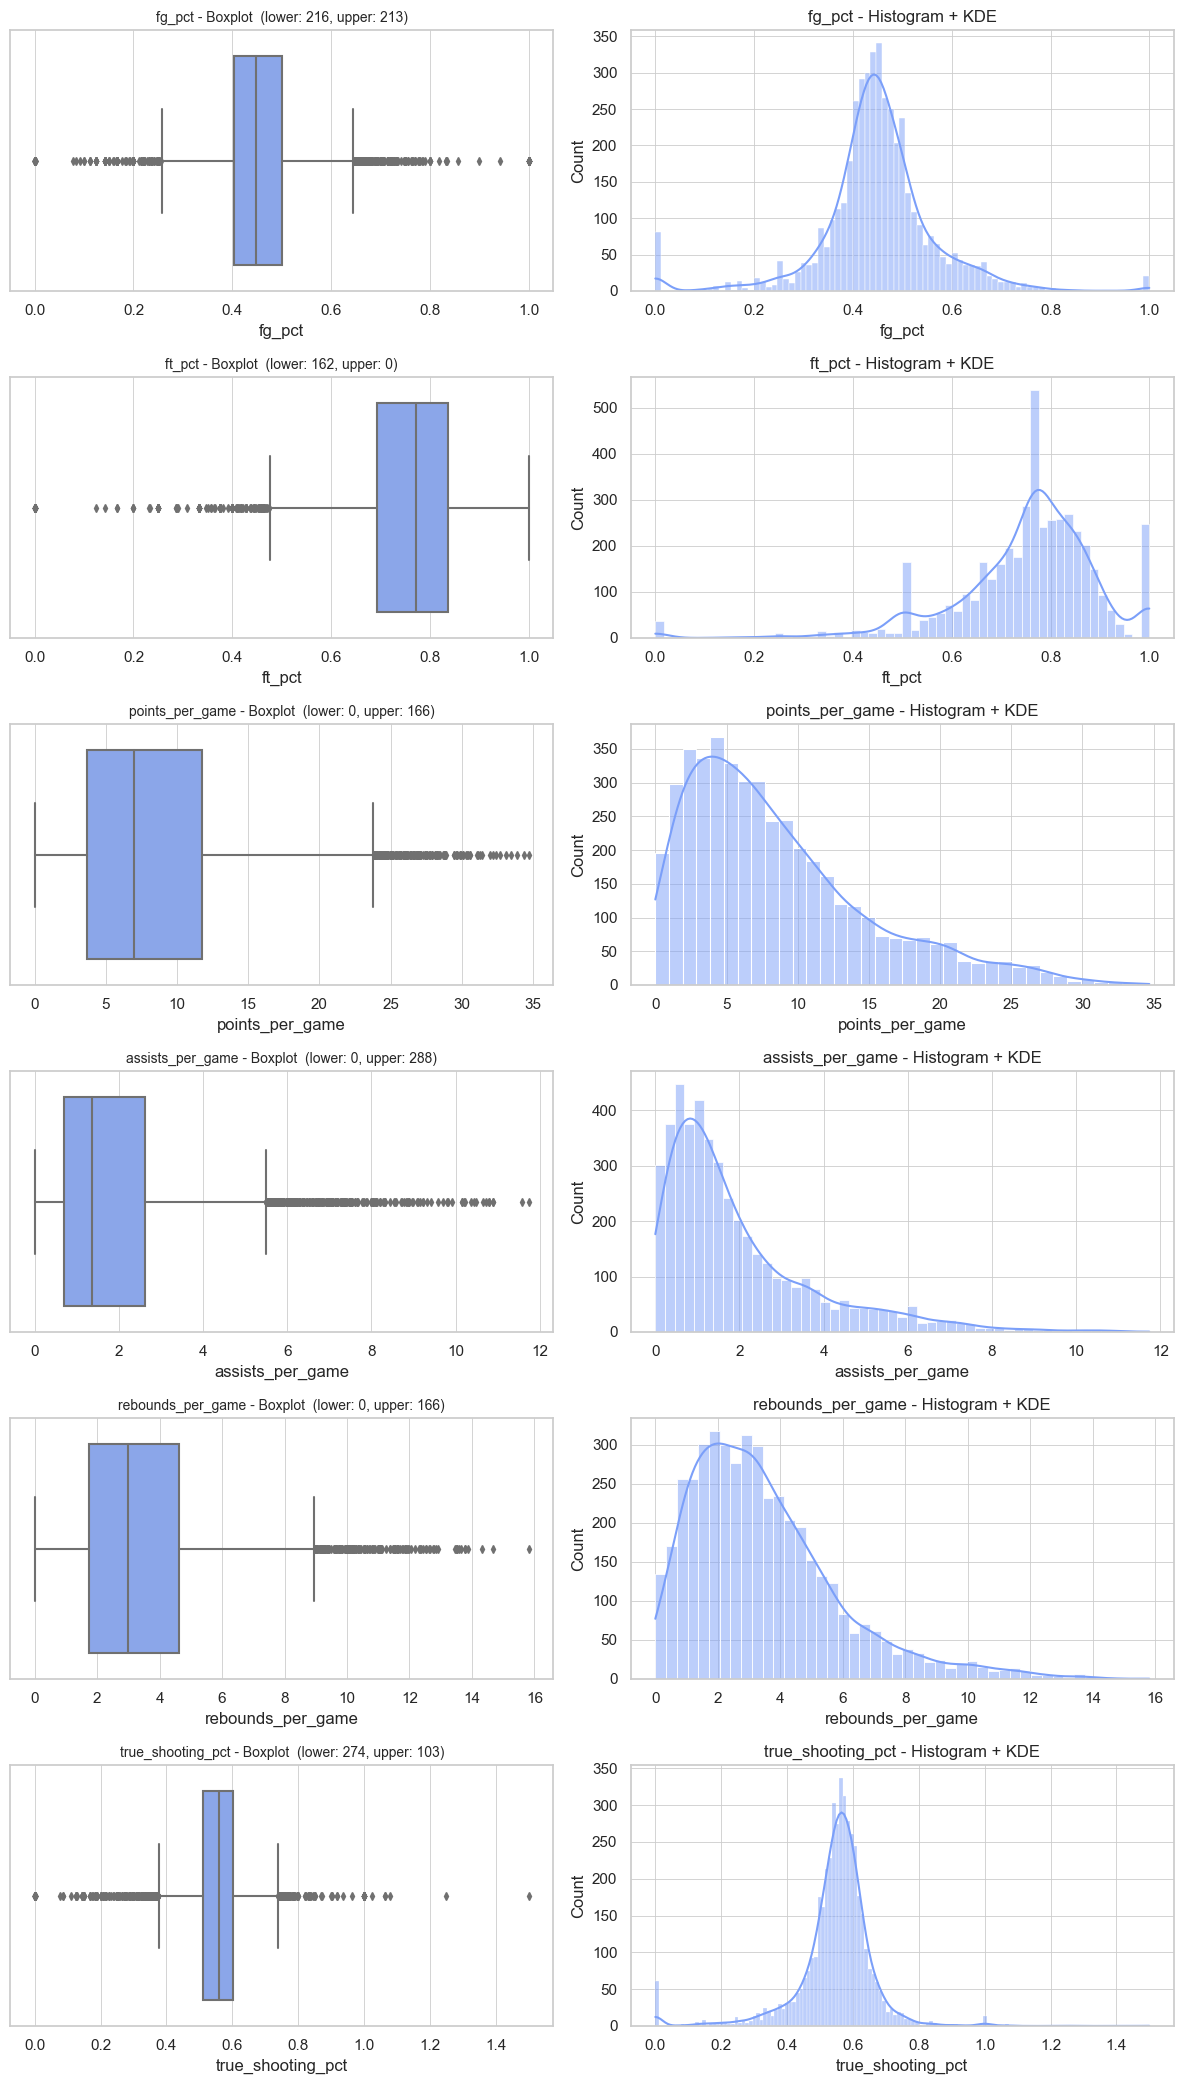

In [185]:
plot_numeric_overview(data, ["fg_pct", "ft_pct", "points_per_game", "assists_per_game", "rebounds_per_game", "true_shooting_pct"], k=1.5)

In [ ]:
def plot_categorical_overview(df, categorical_cols, ncols=3, top_n=8):
    n = len(categorical_cols)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        counts = df[col].value_counts(dropna=False)

        # collapse long tails into "Other" so the pie stays readable
        if len(counts) > top_n:
            top = counts.iloc[:top_n]
            other = pd.Series({"Other": counts.iloc[top_n:].sum()})
            counts = pd.concat([top, other])

        # use the Target palette for binary 0/1 columns, fallback palette otherwise
        if set(counts.index) <= {0, 1}:
            colors = [TARGET_PALETTE[v] for v in counts.index]
        else:
            colors = [FALLBACK_PALETTE[j % len(FALLBACK_PALETTE)] for j in range(len(counts))]

        wedges, _, autotexts = ax.pie(
            counts,
            labels=counts.index.astype(str),
            autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",
            colors=colors,
            startangle=90,
            pctdistance=0.78,
            wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5),
            textprops=dict(fontsize=9),
        )
        for t in autotexts:
            t.set_color("white")
            t.set_fontweight("bold")

        ax.set_title(col, fontsize=12, fontweight="bold", y=1.0)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Categorical Columns Overview", fontsize=16, fontweight="bold")
    plt.tight_layout(pad=1.5, w_pad=2.5, h_pad=1.5, rect=[0, 0, 1, 0.97])
    plt.show()

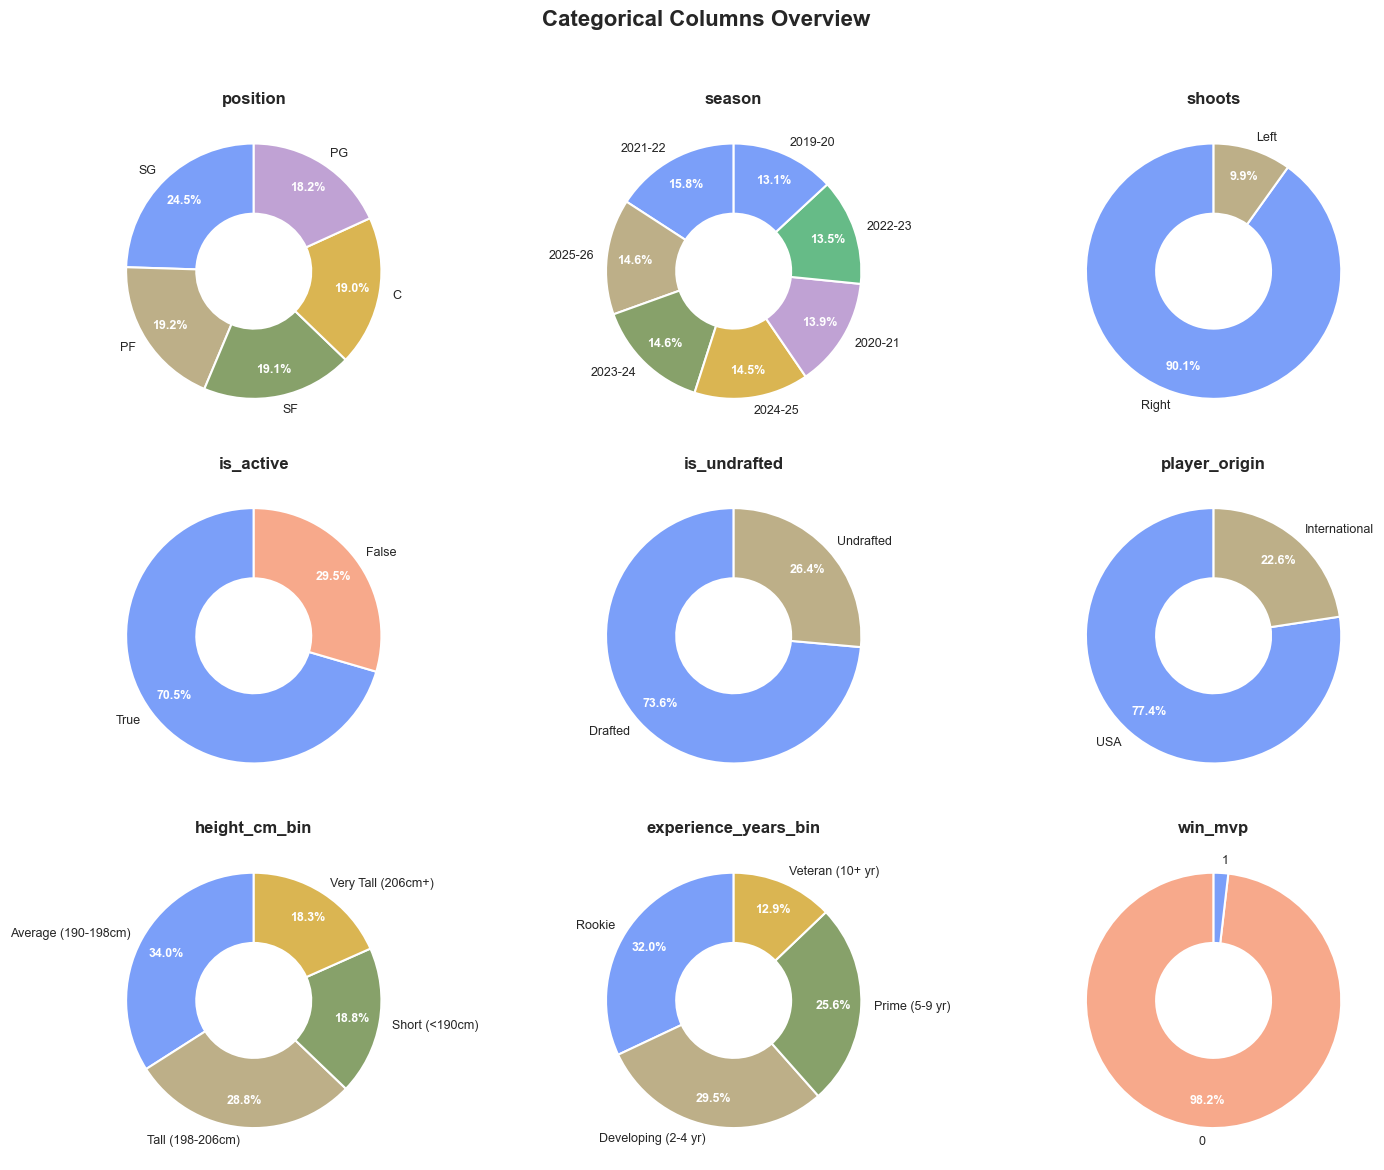

In [186]:
plot_categorical_overview(data, categorical_columns_pp)

## Correlation Overview

#### For numeric columns

In [ ]:
def corr_heatmap(numeric_df, method="spearman"):
    cor = numeric_df.corr(method=method)
    plt.figure(figsize=(20,10))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
                annot_kws={"size": 10})
    plt.title(f"Correlation Heatmap: {method}")
    plt.tight_layout()
    plt.show()

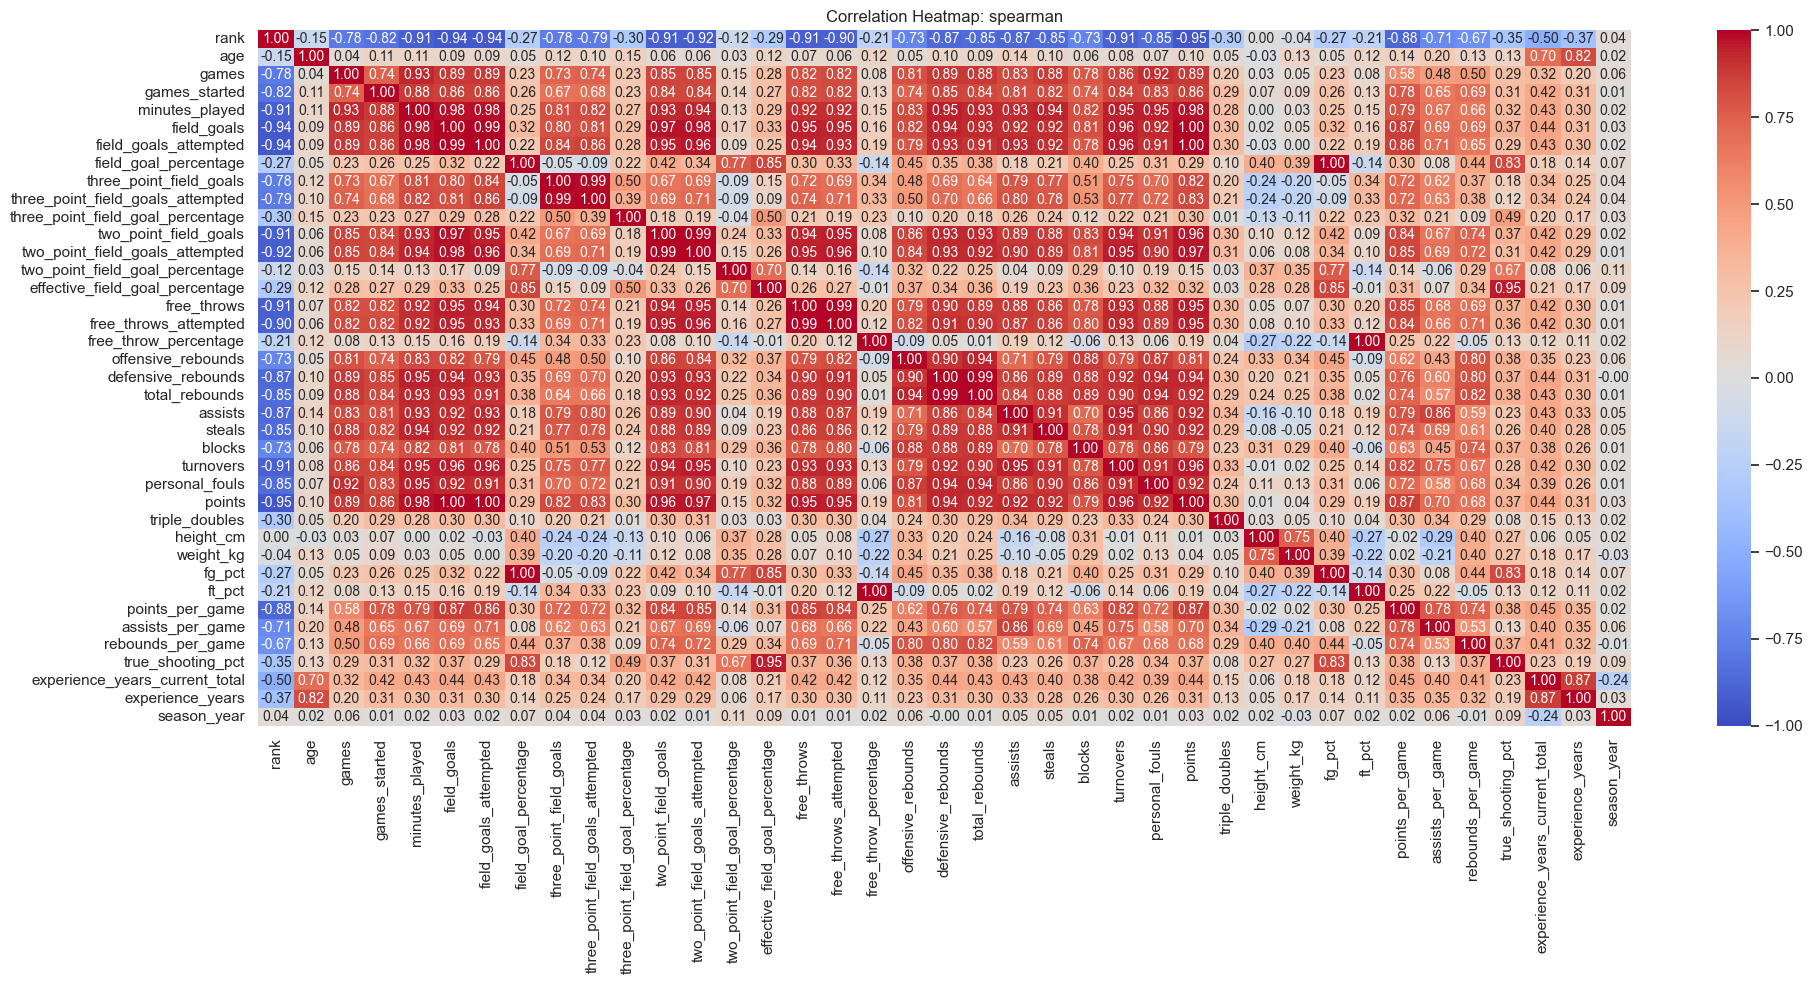

In [187]:
corr_heatmap(data[numeric_columns_pp], method="spearman")

## Two-variable comparison

### Numeric vs Categorical Plot

In [ ]:
def numeric_vs_categorical_plot(df, col, target="Target"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"{col} by {target}", fontsize=14, fontweight="bold")

    target_values = sorted(df[target].dropna().unique())
    if set(target_values).issubset(TARGET_PALETTE.keys()):
        palette = TARGET_PALETTE
    else:
        palette = dict(zip(target_values, FALLBACK_PALETTE[:len(target_values)]))

    sns.histplot(data=df, x=col, hue=target, multiple="stack", palette=palette, ax=axes[0])
    axes[0].set_title("Stacked count")

    sns.histplot(data=df, x=col, hue=target, multiple="fill", palette=palette, ax=axes[1])
    axes[1].set_title("Proportion")

    sns.boxplot(data=df, x=target, y=col, palette=palette, ax=axes[2])
    axes[2].set_title("Boxplot")

    plt.tight_layout()
    plt.show()

In [ ]:
for col in numeric_columns_pp:
    numeric_vs_categorical_plot(data, col)

### Categorical vs Categorical Plot

In [165]:
def two_categorical_plot(df, col, target="Target"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)
    fig.suptitle(col, fontsize=14, fontweight="bold")

    order = df[col].value_counts().index
    target_values = sorted(df[target].dropna().unique())

    if set(target_values).issubset(TARGET_PALETTE.keys()):
        palette = TARGET_PALETTE
    else:
        palette = dict(zip(target_values, FALLBACK_PALETTE[:len(target_values)]))

    cont_table = pd.crosstab(df[col], df[target])
    sns.heatmap(cont_table, annot=True, fmt=".0f", cmap=soft_coolwarm, cbar=False, ax=axes[0, 0])

    prop_table = pd.crosstab(df[col], df[target], normalize="index")
    sns.heatmap(prop_table, annot=True, fmt=".2%", cmap=soft_coolwarm, cbar=False, ax=axes[0, 1])

    sns.countplot(data=df, x=col, hue=target, order=order, palette=palette, ax=axes[1, 0])
    axes[1, 0].tick_params(axis="x", rotation=45)
    axes[1, 0].set_title("Grouped count")

    ct = pd.crosstab(df[col], df[target], normalize="index").reindex(order)
    ct.plot(kind="bar", stacked=True, color=[palette[v] for v in ct.columns], ax=axes[1, 1])
    axes[1, 1].tick_params(axis="x", rotation=45)
    axes[1, 1].set_title("Proportion by " + target)

    plt.tight_layout()
    plt.show()

### Numeric vs Numeric Plot

In [190]:
def numeric_vs_numeric_plot(df, x, y, hue=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{x} vs {y}", fontsize=14, fontweight="bold")

    clean = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    pearson_r, pearson_p = pearsonr(clean[x], clean[y])
    spearman_r, spearman_p = spearmanr(clean[x], clean[y])

    # scatter + regression line
    sns.regplot(
        data=df, x=x, y=y, ax=axes[0],
        scatter_kws=dict(alpha=0.35, s=18, color=Blue, edgecolor="none"),
        line_kws=dict(color=Orange, linewidth=2.2),
    )
    axes[0].set_title(
        f"pearson r={pearson_r:.2f} (p={pearson_p:.1g})   |   spearman ρ={spearman_r:.2f}",
        fontsize=10
    )
    axes[0].spines[["top", "right"]].set_visible(False)

    #colored by a category if given, otherwise a density view
    if hue is not None:
        hue_values = sorted(df[hue].dropna().unique())
        if set(hue_values).issubset(TARGET_PALETTE.keys()):
            palette = TARGET_PALETTE
        else:
            palette = dict(zip(hue_values, FALLBACK_PALETTE[:len(hue_values)]))

        sns.scatterplot(
            data=df, x=x, y=y, hue=hue, palette=palette,
            alpha=0.5, s=22, edgecolor="none", ax=axes[1]
        )
        axes[1].set_title(f"colored by {hue}", fontsize=11)
        axes[1].legend(frameon=False, title=hue)
    else:
        sns.kdeplot(data=df, x=x, y=y, fill=True, cmap=soft_coolwarm, thresh=0.05, ax=axes[1])
        axes[1].set_title("Density", fontsize=11)

    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

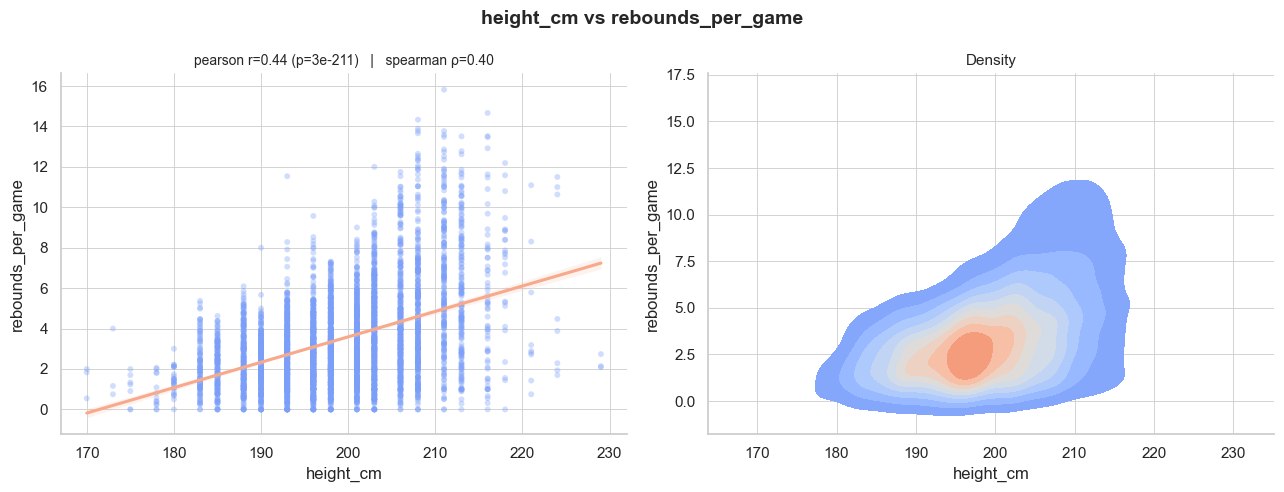

In [188]:
numeric_vs_numeric_plot(data, "height_cm", "rebounds_per_game")

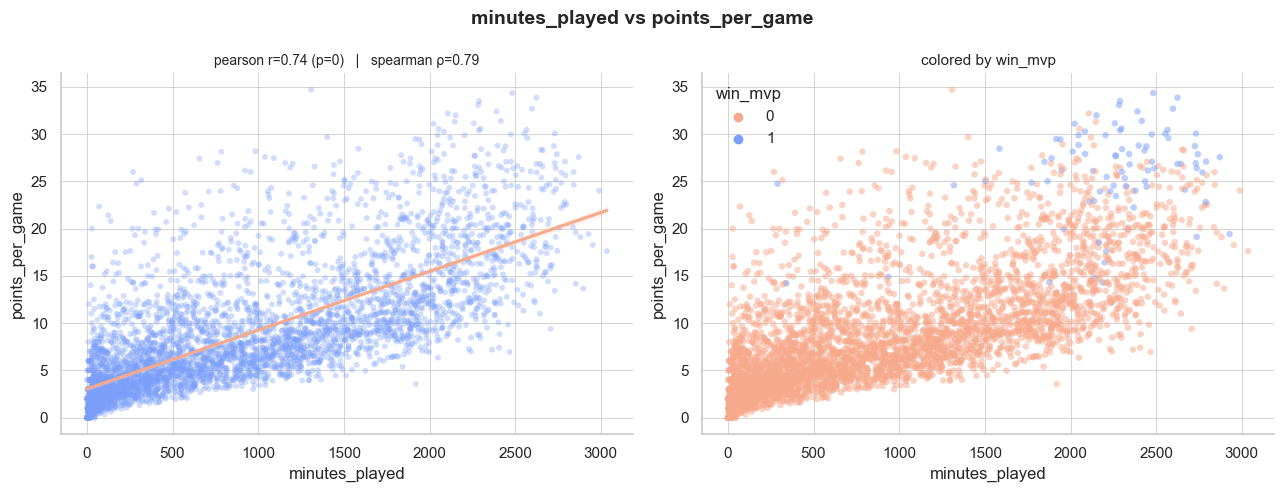

In [189]:
numeric_vs_numeric_plot(data, "minutes_played", "points_per_game", hue="win_mvp")

### Season Trend Plot

In [ ]:
def plot_season_trend(df, col, season_col="season", season_order_col="season_year", hue=None):
    fig, ax = plt.subplots(figsize=(10, 5))

    order = (
        df[[season_col, season_order_col]]
        .drop_duplicates()
        .sort_values(season_order_col)[season_col]
    )

    if hue is not None:
        hue_values = sorted(df[hue].dropna().unique())
        if set(hue_values).issubset(TARGET_PALETTE.keys()):
            palette = TARGET_PALETTE
        else:
            palette = dict(zip(hue_values, FALLBACK_PALETTE[:len(hue_values)]))

        summary = df.groupby([season_col, hue])[col].mean().reset_index()
        for val in hue_values:
            sub = summary[summary[hue] == val].set_index(season_col).reindex(order)
            ax.plot(order, sub[col], marker="o", linewidth=2.2, label=str(val), color=palette[val])
        ax.legend(title=hue, frameon=False)
    else:
        summary = df.groupby(season_col)[col].agg(["mean", "std", "count"]).reindex(order)
        se = summary["std"] / np.sqrt(summary["count"])
        ax.plot(order, summary["mean"], marker="o", linewidth=2.2, color=Blue)
        ax.fill_between(
            range(len(order)), summary["mean"] - se, summary["mean"] + se,
            color=Blue, alpha=0.15, label="± SE"
        )
        ax.legend(frameon=False)

    ax.set_title(f"{col} by season", fontsize=13, fontweight="bold", loc="left")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", visible=False)

    plt.tight_layout()
    plt.show()

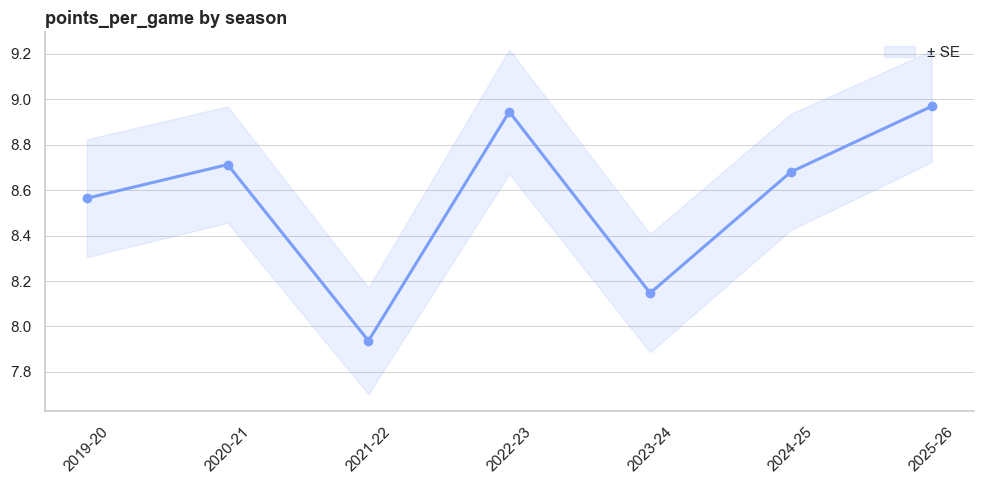

In [191]:
plot_season_trend(data, "points_per_game")

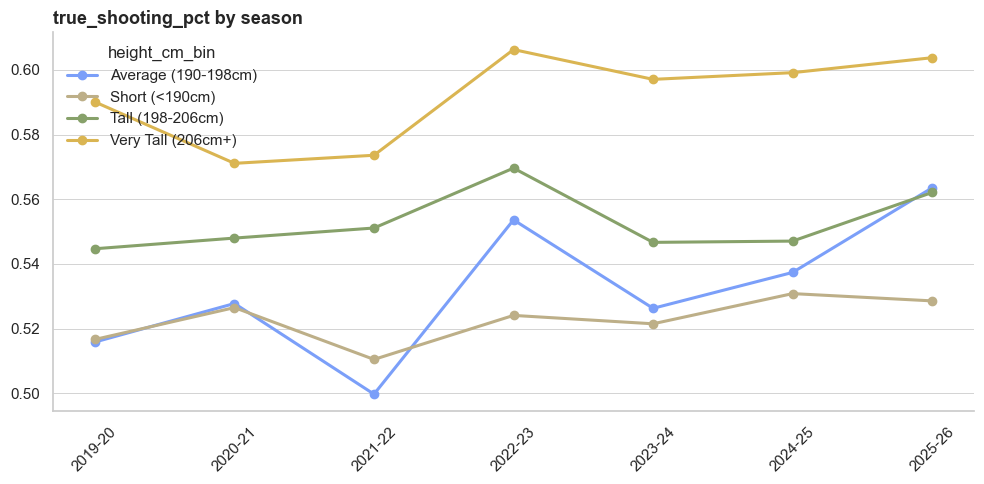

In [192]:
plot_season_trend(data, "true_shooting_pct", hue="height_cm_bin")

In [135]:
def anova_boxplot(df, group_col, value_col, palette=None):
    order = df.groupby(group_col)[value_col].median().sort_values(ascending=False).index
    colors = palette or [FALLBACK_PALETTE[i % len(FALLBACK_PALETTE)] for i in range(df[group_col].nunique())]

    plt.figure(figsize=(8, 4.5))
    sns.boxplot(data=df, x=group_col, y=value_col, order=order, palette=colors)
    sns.stripplot(data=df, x=group_col, y=value_col, order=order, color="black", alpha=0.15, size=2)
    plt.title(f"{value_col} by {group_col}", fontsize=12, fontweight="bold", loc="left")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

# Exploratory Data Analysis (EDA)

### Confidence Interval Analysis

- Confidence intervals estimate the likely range for the true population mean of a numeric
  variable, based on the sample we have.
- Applied here to `points_per_game`, `minutes_played`, and `true_shooting_pct` — instead of
  reporting only the sample mean, we report a 95% confidence interval so the result also
  communicates uncertainty.

In [145]:
def mean_ci(data, column, confidence=0.95):

    x = data[column].replace([np.inf, -np.inf], np.nan).dropna()
    n = len(x)
    mean = x.mean()
    std = x.std(ddof=1)
    se = std / np.sqrt(n)

    alpha = 1 - confidence
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margin_error = t_critical * se

    result = pd.DataFrame({
        "Variable": [column],
        "Type": "Mean CI",
        "N": n,
        "Sample Mean": round(mean, 3),
        "Sample Std": round(std, 3),
        "Confidence Level": confidence,
        "CI Lower": round(mean - margin_error, 3),
        "CI Upper": round(mean + margin_error, 3),
    })

    return result

### ANOVA: numeric outcome across a multi-category variable

In [146]:
def anova_test_pro(df, group_col, target_col, equal_var=True):
    temp = df[[group_col, target_col]].dropna().copy()

    if temp[group_col].nunique() < 2:
        print("Insufficient Groups")
        return None, None, "Insufficient Groups"

    if equal_var:
        groups = [
            g[target_col].values
            for _, g in temp.groupby(group_col)
            if len(g) > 0
        ]
        f_stat, p = f_oneway(*groups)
        test_name = "Classic ANOVA"
    else:
        res = anova_oneway(
            data=temp[target_col],
            groups=temp[group_col],
            use_var="unequal"
        )
        f_stat = res.statistic
        p = res.pvalue
        test_name = "Welch ANOVA"

    result = "Significant" if p < 0.05 else "Not Significant"

    print(f"Test used: {test_name}")
    print(f"F-stat = {f_stat:.4f}")
    print(f"p-value = {p:.4g}")
    print(f"Result: {result}")


    return f_stat, p, result

In [147]:
def get_residuals(df, value_col, group_col):
    return df[value_col] - df.groupby(group_col)[value_col].transform('mean')

In [148]:
def levene_test(df, group_col, value_col, center='median'):
    groups = []

    for group in df[group_col].dropna().unique():
        sample = df.loc[df[group_col] == group, value_col].dropna()
        if len(sample) > 0:
            groups.append(sample)

    if len(groups) < 2:
        raise ValueError("Need at least 2 groups with data for Levene test.")

    stat, p = levene(*groups, center=center)
    print(f"P-value is: {p}")

### Chi-square test of independence between two categorical variables

- **Null Hypothesis (H0):** the two categorical variables are independent.
- **Alternative Hypothesis (H1):** the two categorical variables are associated.
- If p-value < 0.05, reject H0.

In [149]:
def compare_two_categorical(df, col_1, col_2, alpha=0.05):

    two_categorical_plot(df, col_1, col_2)

    contingency_table = pd.crosstab(df[col_1], df[col_2])
    chi2_stat, p_value, dof, expected_table = chi2_contingency(contingency_table)

    print(f"chi2_stat: {chi2_stat:.4f}")
    print(f"p-value: {p_value:.4g}")

    if p_value < alpha:
        print("Reject the Null Hypothesis")
        print(f"There IS a significant association between '{col_1}' and '{col_2}'.")
    else:
        print("Fail to Reject the Null Hypothesis")
        print(f"There is NO significant association between '{col_1}' and '{col_2}'.")

### Numeric vs categorical (binary target)

To compare a continuous feature against a binary target, first check normality per group
(Shapiro-Wilk). If both groups are normal, use an independent-samples t-test. If not, attempt
a Box-Cox transform and re-test; if it still isn't normal, fall back to the non-parametric
Mann-Whitney U test.

In [150]:
def numeric_vs_categorical(data, col_1, col_2, alpha=0.05):

    numeric_vs_categorical_plot(data, col_1, col_2)

    categories = data[col_2].dropna().unique()
    X1 = data.loc[data[col_2] == categories[0], col_1].replace([np.inf, -np.inf], np.nan).dropna()
    X2 = data.loc[data[col_2] == categories[1], col_1].replace([np.inf, -np.inf], np.nan).dropna()

    shapiro_p0 = stats.shapiro(X1.sample(min(len(X1), 5000), random_state=42)).pvalue
    shapiro_p1 = stats.shapiro(X2.sample(min(len(X2), 5000), random_state=42)).pvalue
    print(f"Shapiro group '{categories[0]}': p = {shapiro_p0:.4g}")
    print(f"Shapiro group '{categories[1]}': p = {shapiro_p1:.4g}")

    if shapiro_p0 > alpha and shapiro_p1 > alpha:
        t, p = stats.ttest_ind(X1, X2)
        print("Normal distribution -> t-test")
        print(f"t = {t:.4f}, p = {p:.4g}")
    else:
        try:
            X1_bc, _ = stats.boxcox(X1 - X1.min() + 1)
            X2_bc, _ = stats.boxcox(X2 - X2.min() + 1)
            shapiro_p0_bc = stats.shapiro(X1_bc.sample(min(len(X1_bc), 5000)) if hasattr(X1_bc, "sample") else X1_bc[:5000]).pvalue
            shapiro_p1_bc = stats.shapiro(X2_bc[:5000]).pvalue

            if shapiro_p0_bc > alpha and shapiro_p1_bc > alpha:
                t, p = stats.ttest_ind(X1_bc, X2_bc)
                print("Normal after Box-Cox -> t-test")
                print(f"t = {t:.4f}, p = {p:.4g}")
            else:
                u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
                print("Not normal after Box-Cox -> Mann-Whitney U")
                print(f"U = {u:.1f}, p = {p:.4g}")
        except Exception:
            u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
            print("Box-Cox not applicable -> Mann-Whitney U")
            print(f"U = {u:.1f}, p = {p:.4g}")

    result = "Significant" if p < alpha else "Not Significant"
    print("Result:", result)
    return p

### numeric-vs-numeric

In [158]:
def numeric_vs_numeric_test(df, x, y, alpha=0.05):
    numeric_vs_numeric_plot(df, x, y)
    clean = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    rho, p = spearmanr(clean[x], clean[y])
    result = "Significant" if p < alpha else "Not Significant"
    print(f"Spearman rho = {rho:.4f}, p = {p:.4g}")
    print("Result:", result)
    return rho, p

In [151]:
mean_ci(data, "points_per_game")

,Variable,Type,N,Sample Mean,Sample Std,Confidence Level,CI Lower,CI Upper
0,points_per_game,Mean CI,4513,8.552,6.479,0.95,8.363,8.741


In [ ]:
mean_ci(data, "minutes_played")

In [ ]:
mean_ci(data, "true_shooting_pct")

### Q1: Do positions differ in scoring?

- **Variables:** `position_main`, `points_per_game`
- **Test:** Welch's one-way ANOVA (unequal variances -- see diagnostics above)
- **H0:** the mean `points_per_game` is the same across all positions.
- **H1:** at least one position has a different mean.

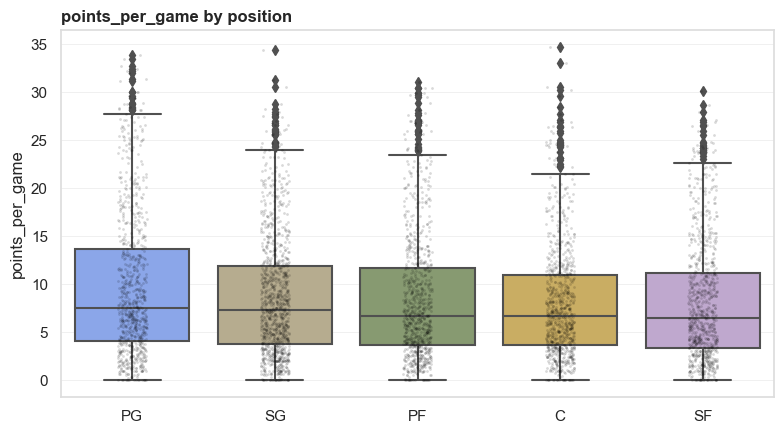

Test used: Welch ANOVA
F-stat = 8.5399
p-value = 7.764e-07
Result: Significant


(8.539881332740796, 7.764465044041174e-07, 'Significant')

In [137]:
anova_boxplot(data, "position", "points_per_game")
anova_test_pro(data, "position", "points_per_game", equal_var=False)

### Q2: Do positions differ in blocking, passing, or rebounding?

- **Variables:** `position_main`, `blocks`, `assists`, `offensive_rebounds`
- **Test:** Welch's one-way ANOVA
- **H0:** the mean stat is the same across all positions.
- **H1:** at least one position has a different mean.

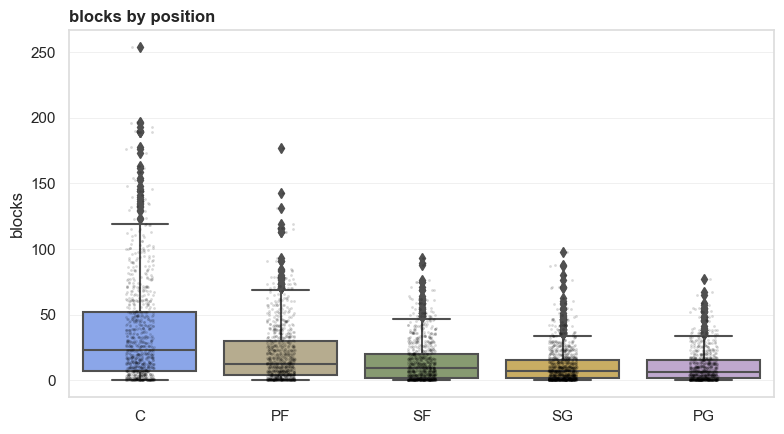

Test used: Welch ANOVA
F-stat = 120.2110
p-value = 1.293e-92
Result: Significant


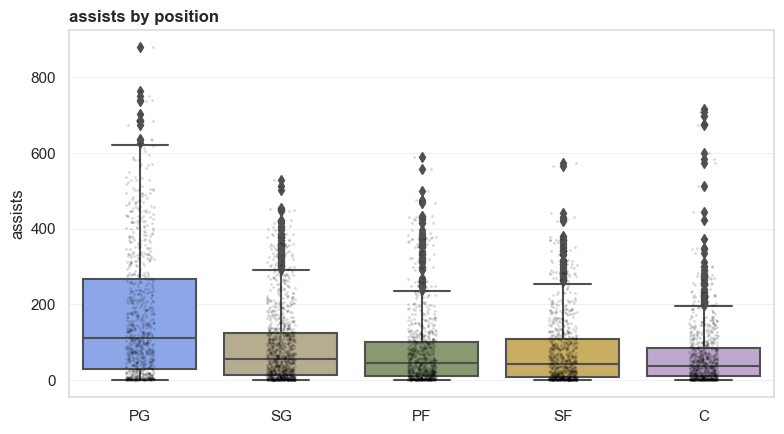

Test used: Welch ANOVA
F-stat = 66.5345
p-value = 3.425e-53
Result: Significant


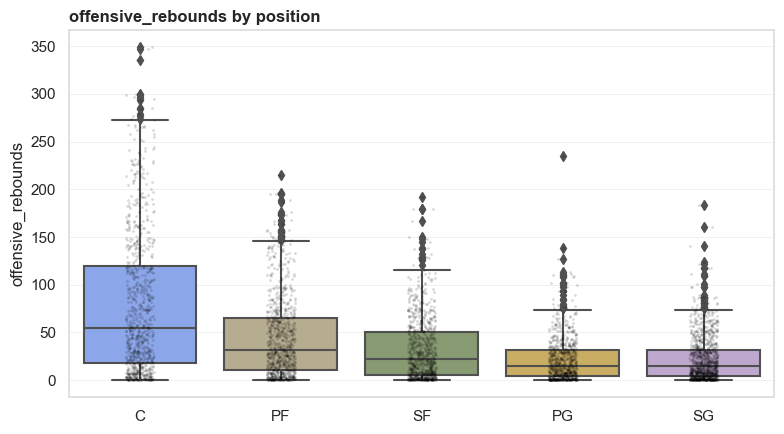

Test used: Welch ANOVA
F-stat = 169.8757
p-value = 2.363e-126
Result: Significant


In [139]:
for stat in ["blocks", "assists", "offensive_rebounds"]:
    anova_boxplot(data, "position", stat)
    anova_test_pro(data, "position", stat, equal_var=False)

### Q3: Do experience groups differ in production?

- **Variables:** `experience_years_bin`, `points`, `assists`, `effective_field_goal_percentage`
- **Test:** Welch's one-way ANOVA
- **H0:** the mean stat is equal across experience groups.
- **H1:** at least one experience group has a different mean.

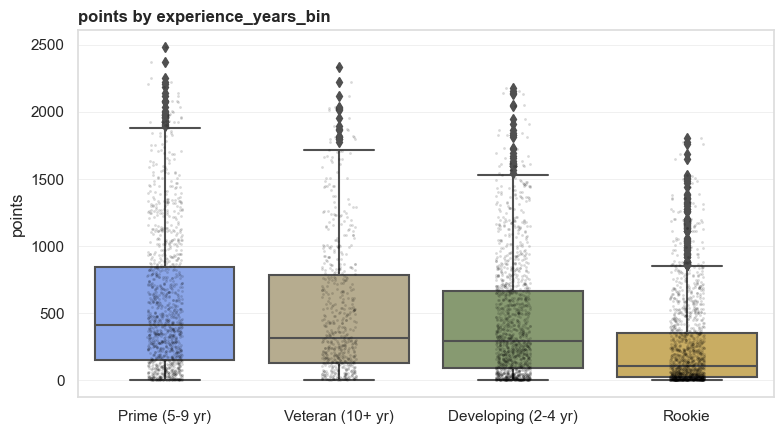

Test used: Welch ANOVA
F-stat = 158.4536
p-value = 1.44e-91
Result: Significant


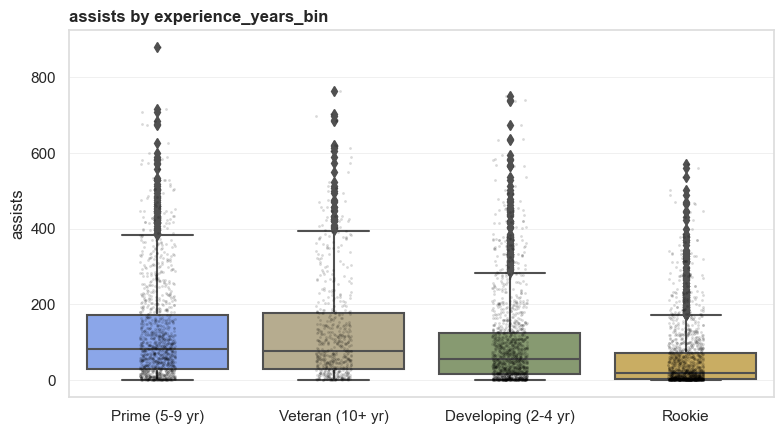

Test used: Welch ANOVA
F-stat = 122.5757
p-value = 1.869e-72
Result: Significant


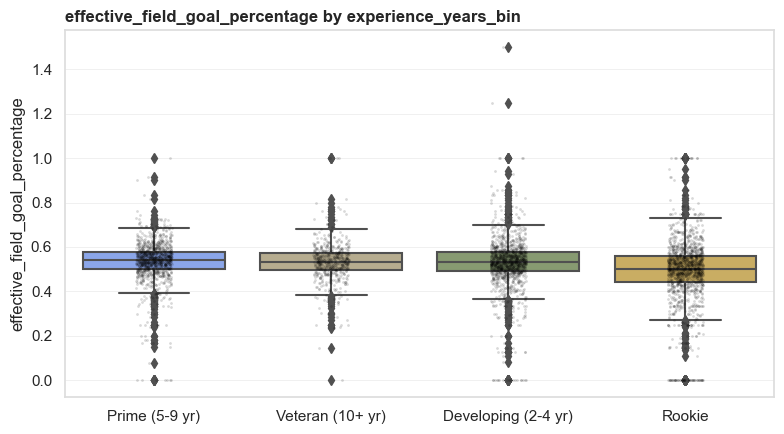

Test used: Welch ANOVA
F-stat = 34.5203
p-value = 8.755e-22
Result: Significant


In [140]:
for stat in ["points", "assists", "effective_field_goal_percentage"]:
    anova_boxplot(data, "experience_years_bin", stat)
    anova_test_pro(data, "experience_years_bin", stat, equal_var=False)

### Q4: Do starters outperform non-starters?

- **Variables:** `is_starter`, `points_per_game`, `effective_field_goal_percentage`, `minutes_played`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of the stat is the same for starters and non-starters.
- **H1:** the distribution of the stat differs between starters and non-starters.

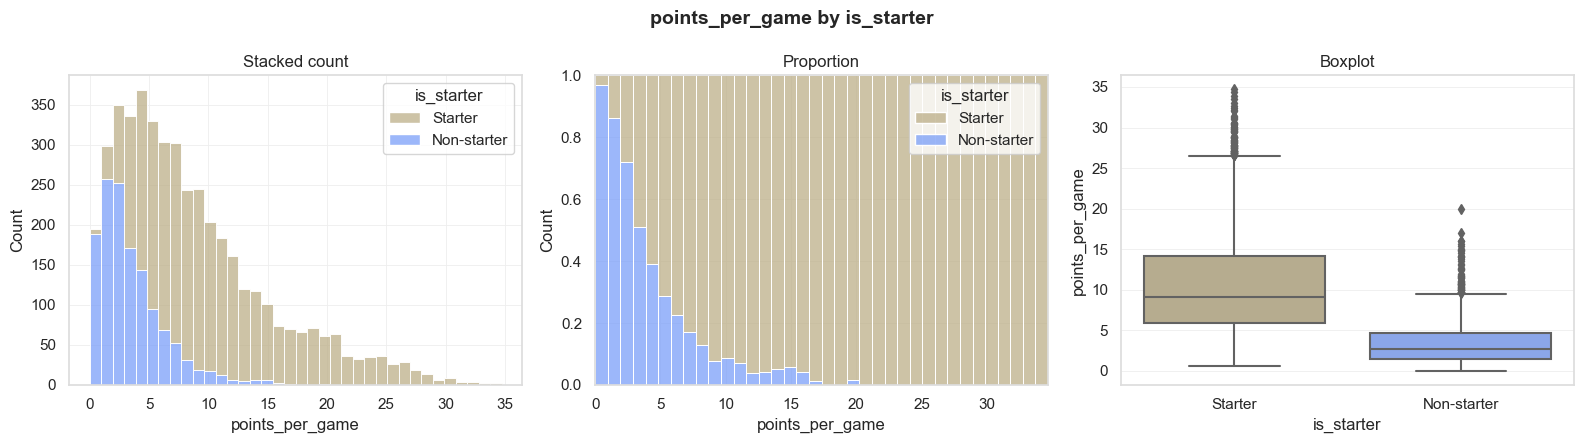

Shapiro group 'Starter': p = 4.392e-37
Shapiro group 'Non-starter': p = 3.02e-31
Not normal after Box-Cox -> Mann-Whitney U
U = 3750287.0, p = 0
Result: Significant


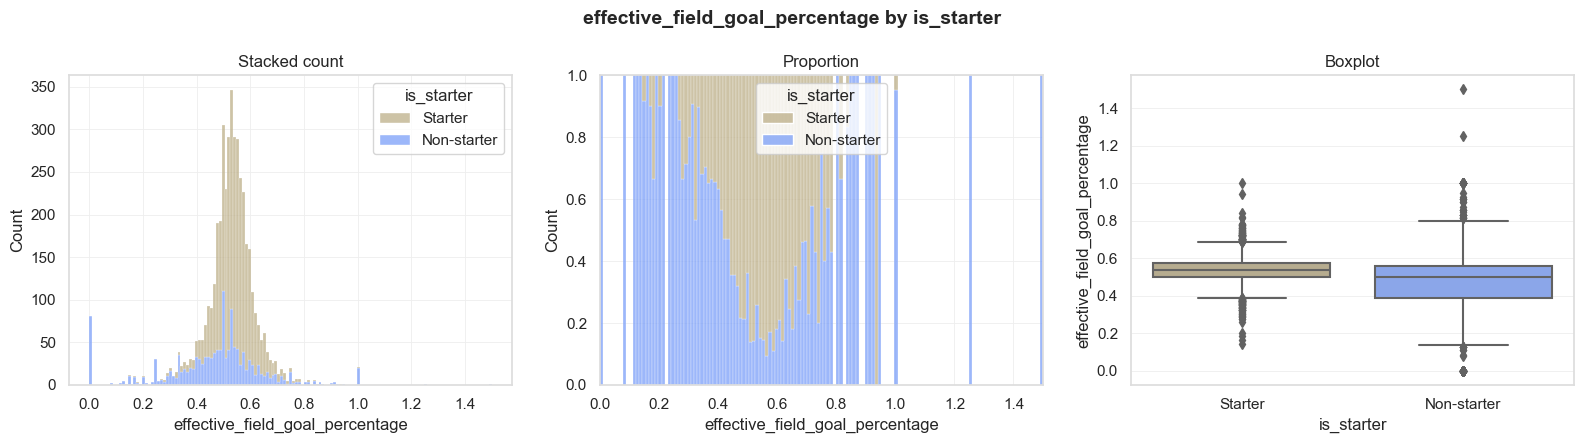

Shapiro group 'Starter': p = 7.462e-26
Shapiro group 'Non-starter': p = 1.272e-23
Not normal after Box-Cox -> Mann-Whitney U
U = 2758992.5, p = 5.43e-57
Result: Significant


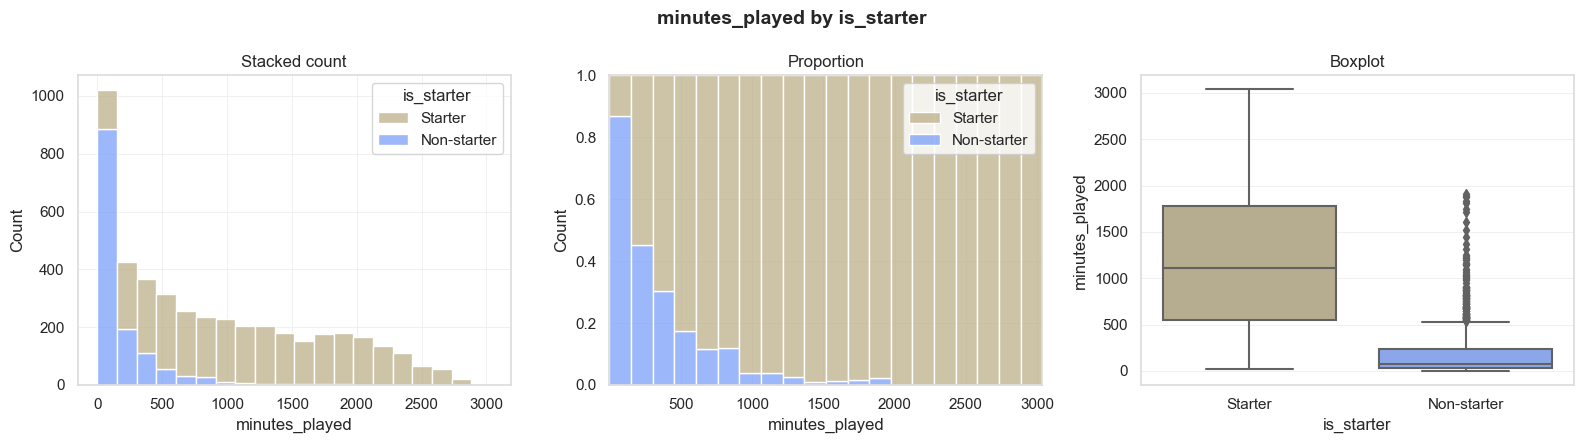

Shapiro group 'Starter': p = 5.87e-29
Shapiro group 'Non-starter': p = 2.757e-45
Not normal after Box-Cox -> Mann-Whitney U
U = 3956725.5, p = 0
Result: Significant


In [141]:
data["is_starter"] = np.where(data["games_started"] == 0, "Non-starter", "Starter")
for stat in ["points_per_game", "effective_field_goal_percentage", "minutes_played"]:
    numeric_vs_categorical(data, stat, "is_starter")

### Q5: Do right-handed players score differently than left-handed players?

- **Variables:** `shoots`, `points_per_game`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of points is the same for right- and left-handed players.
- **H1:** the distribution of points differs between right- and left-handed players.

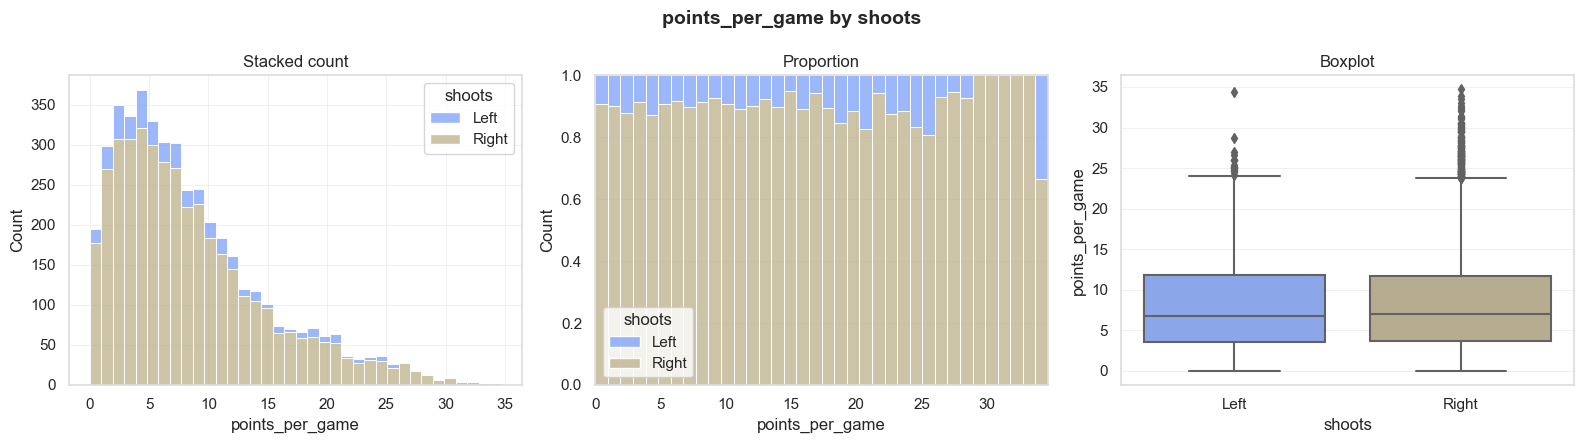

Shapiro group 'Left': p = 1.364e-16
Shapiro group 'Right': p = 5.967e-44
Not normal after Box-Cox -> Mann-Whitney U
U = 898492.5, p = 0.7464
Result: Not Significant


0.7463794809017086

In [142]:
numeric_vs_categorical(data, "points_per_game", "shoots")

### Q6: Are these player attributes associated with winning MVP?

- **Test:** Chi-square test of independence
- **H0:** the categorical variable and `win_mvp` are independent.
- **H1:** the categorical variable and `win_mvp` are associated.

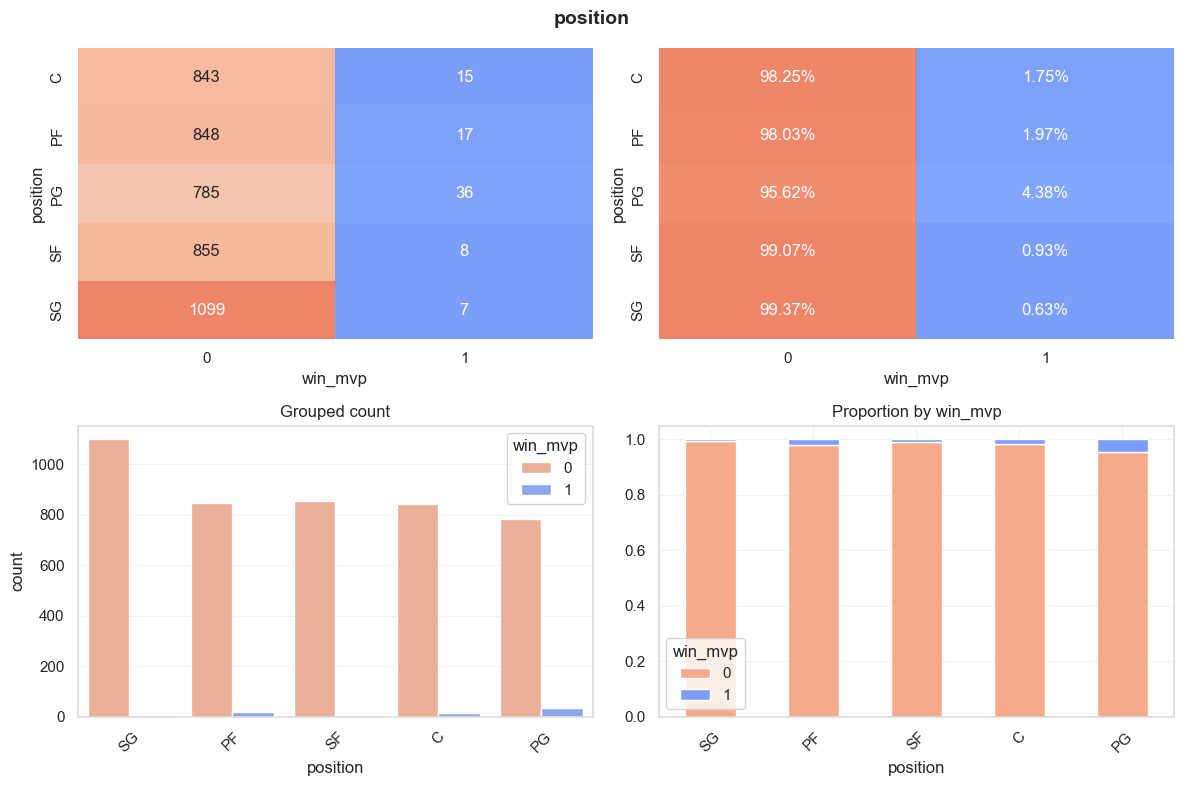

chi2_stat: 42.4797
p-value: 1.327e-08
Reject the Null Hypothesis
There IS a significant association between 'position' and 'win_mvp'.


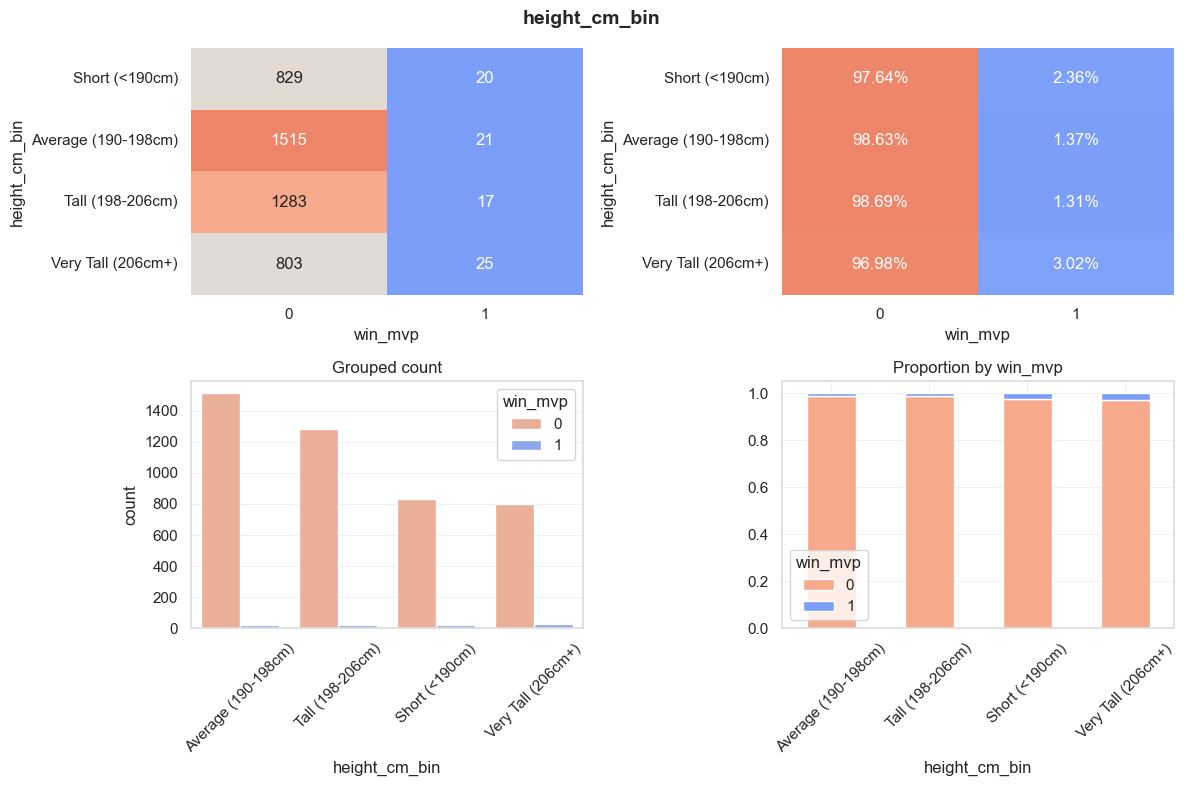

chi2_stat: 11.5721
p-value: 0.009003
Reject the Null Hypothesis
There IS a significant association between 'height_cm_bin' and 'win_mvp'.


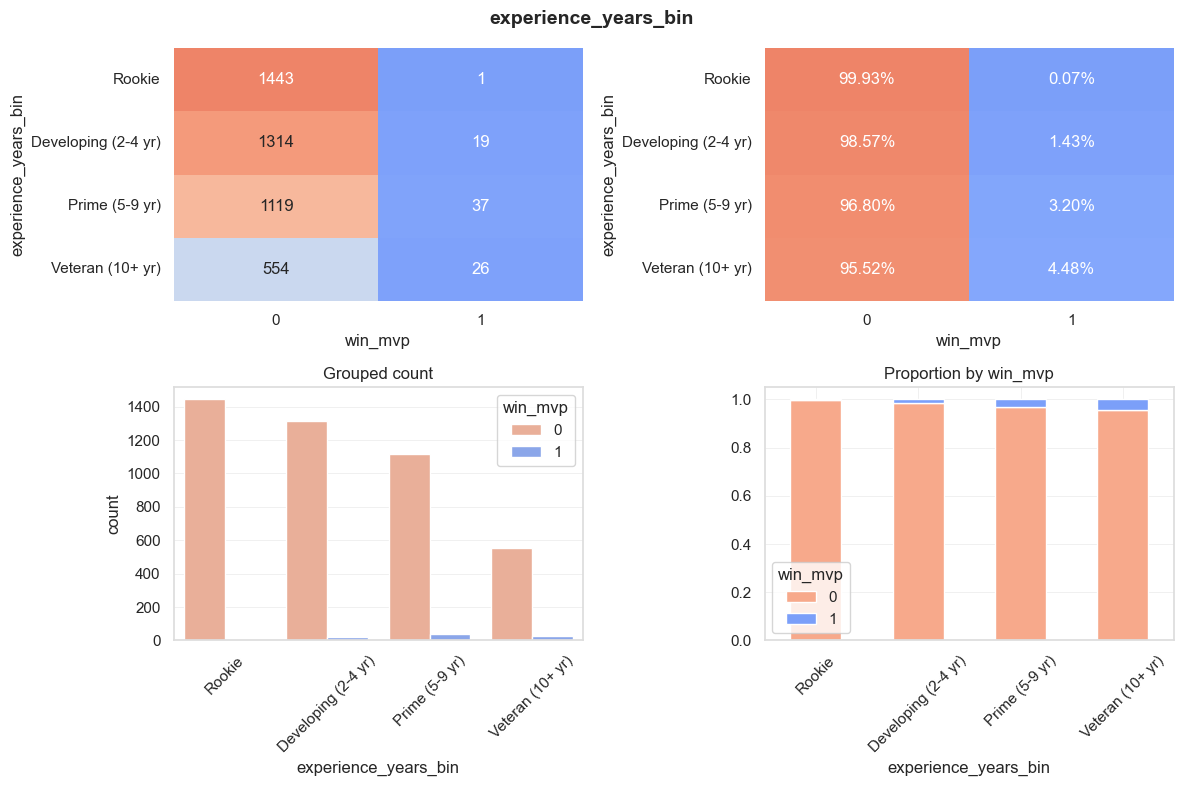

chi2_stat: 60.6437
p-value: 4.283e-13
Reject the Null Hypothesis
There IS a significant association between 'experience_years_bin' and 'win_mvp'.


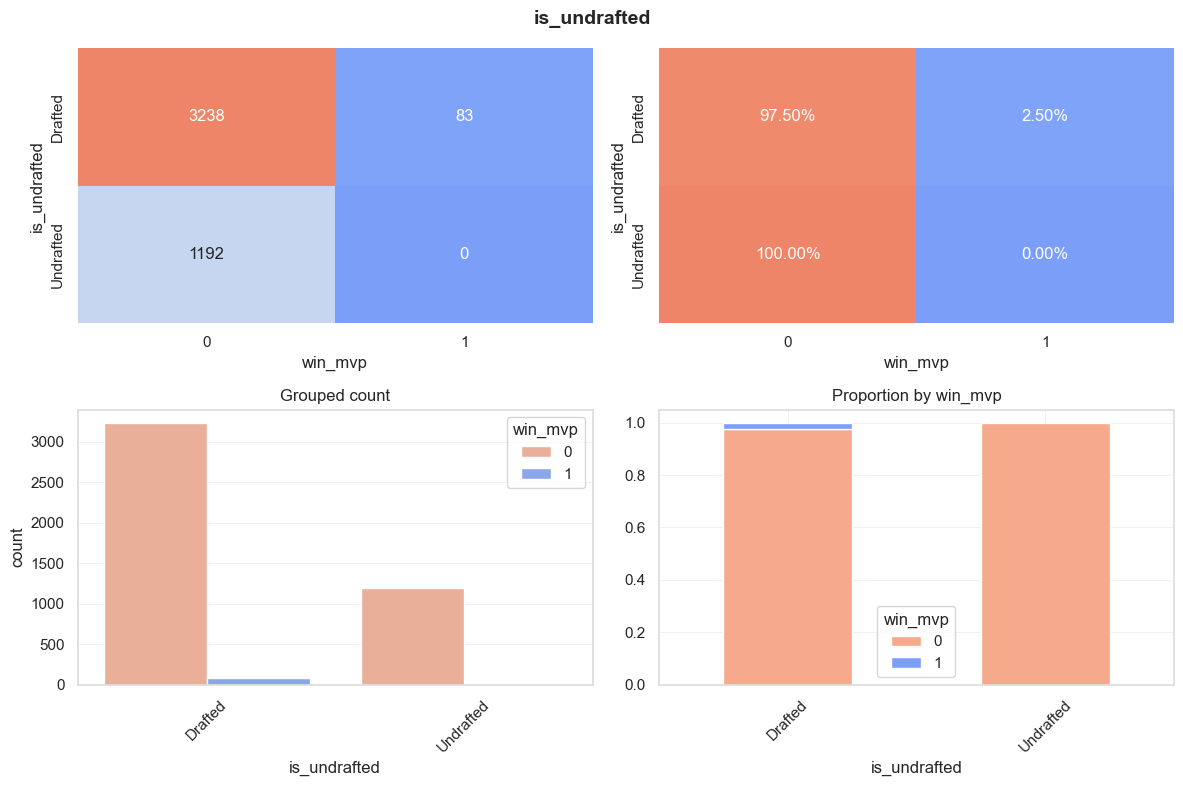

chi2_stat: 28.9806
p-value: 7.311e-08
Reject the Null Hypothesis
There IS a significant association between 'is_undrafted' and 'win_mvp'.


In [166]:
for col in ["position", "height_cm_bin", "experience_years_bin", "is_undrafted"]:
    compare_two_categorical(data, col, target)

### Q7: Is scoring, shooting efficiency, or playing time different for MVP seasons?

- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of the stat is the same for MVP and non-MVP seasons.
- **H1:** MVP seasons have a different (higher) distribution.

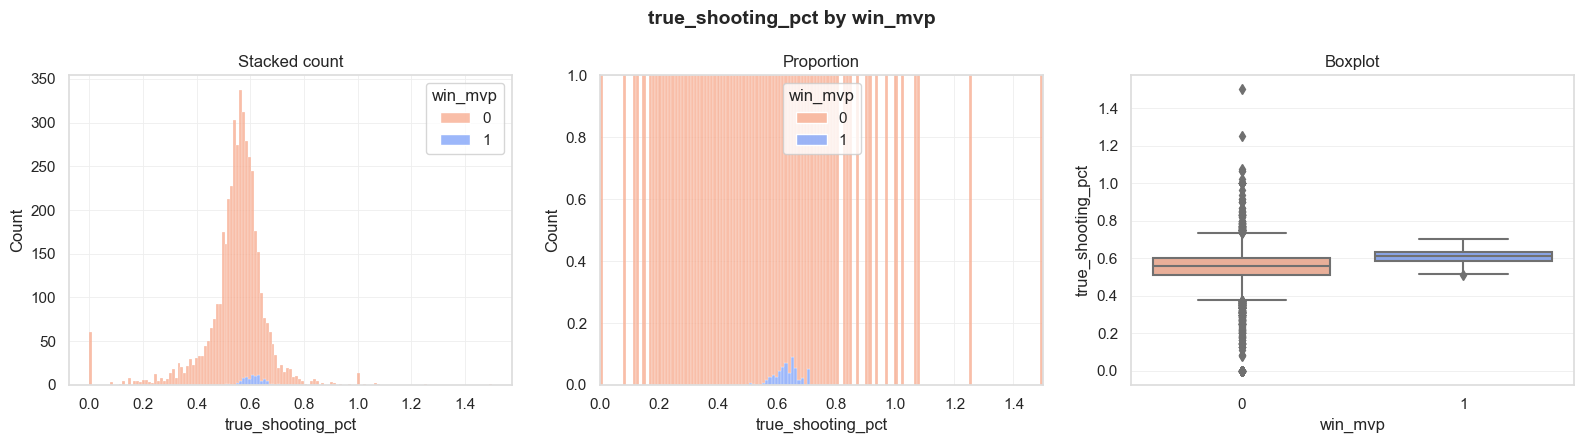

Shapiro group '1': p = 0.7547
Shapiro group '0': p = 5.167e-55
Not normal after Box-Cox -> Mann-Whitney U
U = 278341.5, p = 9.362e-16
Result: Significant


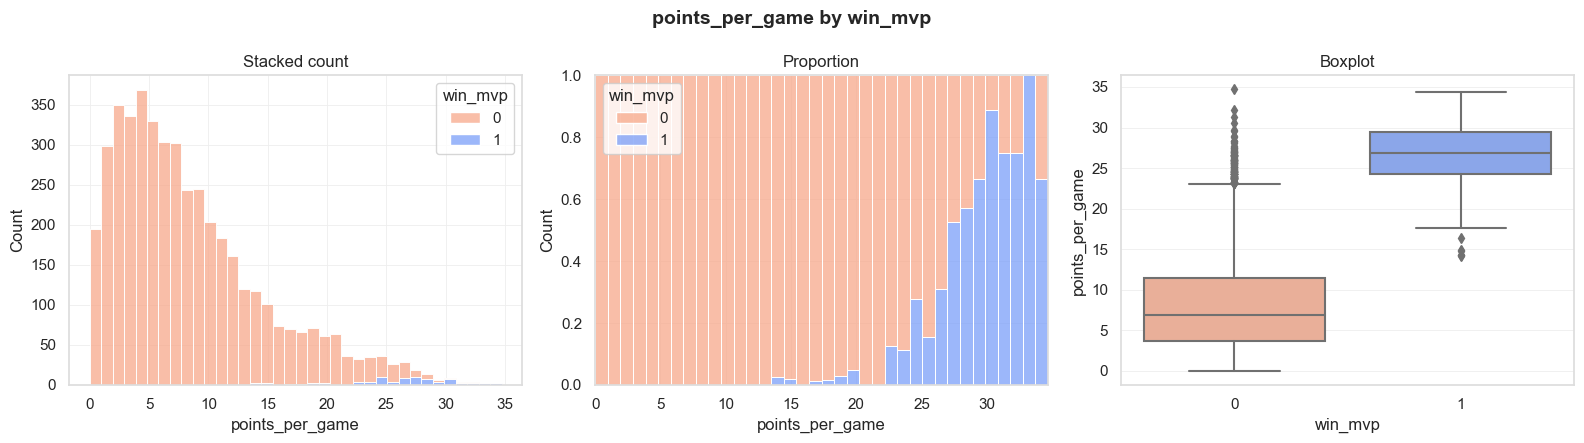

Shapiro group '1': p = 0.00035
Shapiro group '0': p = 2.277e-43
Not normal after Box-Cox -> Mann-Whitney U
U = 359442.5, p = 2.071e-50
Result: Significant


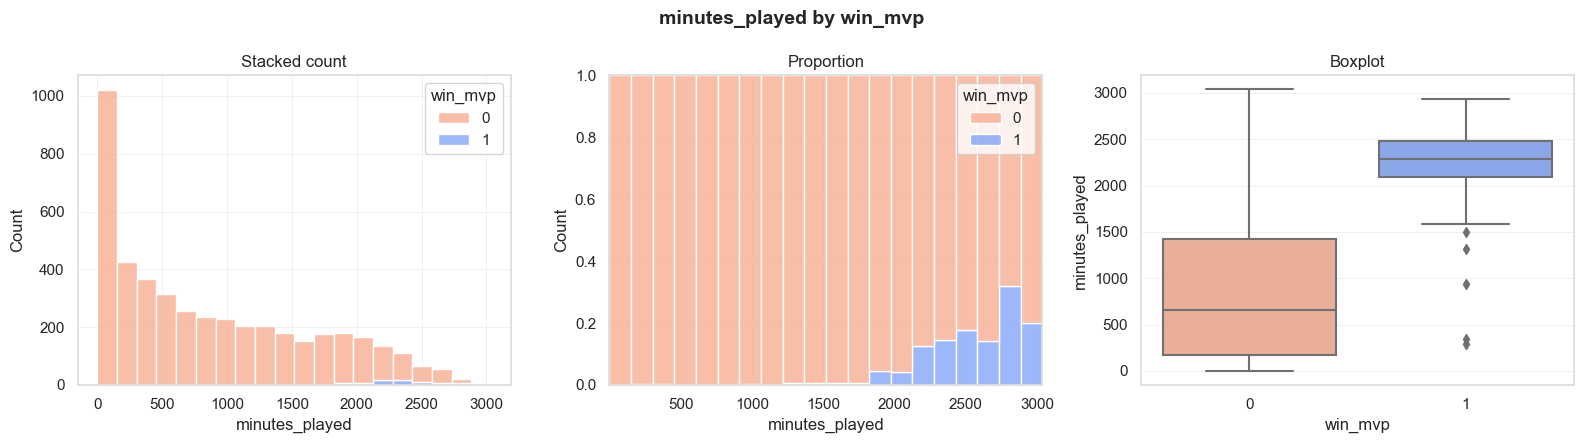

Shapiro group '1': p = 2.172e-08
Shapiro group '0': p = 3.717e-46
Not normal after Box-Cox -> Mann-Whitney U
U = 339593.5, p = 4.942e-40
Result: Significant


In [156]:
for stat in ["true_shooting_pct", "points_per_game", "minutes_played"]:
    numeric_vs_categorical(data, stat, target)

### Q8: Do undrafted players who make an NBA roster get less playing time than drafted players?

- **Variables:** `is_undrafted`, `minutes_played`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of minutes played is the same regardless of draft status.
- **H1:** minutes played differs by draft status.

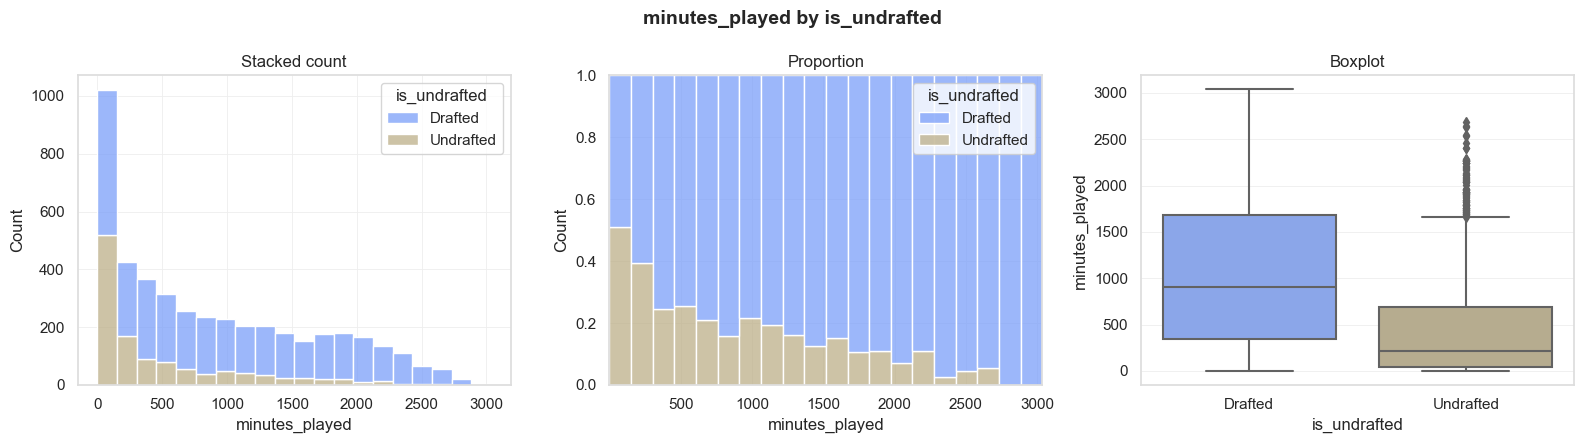

Shapiro group 'Drafted': p = 1.214e-35
Shapiro group 'Undrafted': p = 5.434e-37
Not normal after Box-Cox -> Mann-Whitney U
U = 2894511.0, p = 2.435e-124
Result: Significant


2.4354215117295756e-124

In [157]:
numeric_vs_categorical(data, "minutes_played", "is_undrafted")

### Q9: Does a heavier build predict better rebounding?

- **Variables:** `weight_kg`, `offensive_rebounds`
- **Test:** Spearman correlation significance test
- **H0:** rho = 0 (no monotonic relationship between weight and offensive rebounds).
- **H1:** rho ≠ 0.

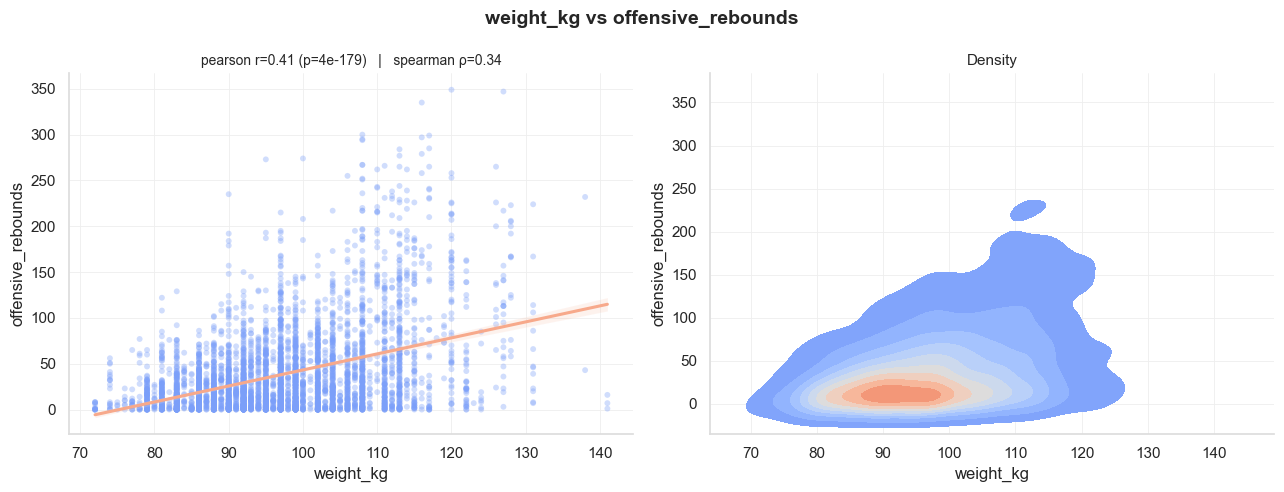

Spearman rho = 0.3353, p = 5.465e-119
Result: Significant


(0.33528157716254336, 5.464619175460971e-119)

In [159]:
numeric_vs_numeric_test(data, "weight_kg", "offensive_rebounds")

### Q10: Does shooting efficiency improve continuously with experience?

- **Variables:** `experience_years`, `true_shooting_pct`
- **Test:** Spearman correlation significance test
- **H0:** rho = 0 (no monotonic relationship between experience and shooting efficiency).
- **H1:** rho ≠ 0.

This is the continuous counterpart to Q3's binned ANOVA -- useful to check whether the
relationship looks smooth/monotonic or whether the binned groups were hiding a plateau.

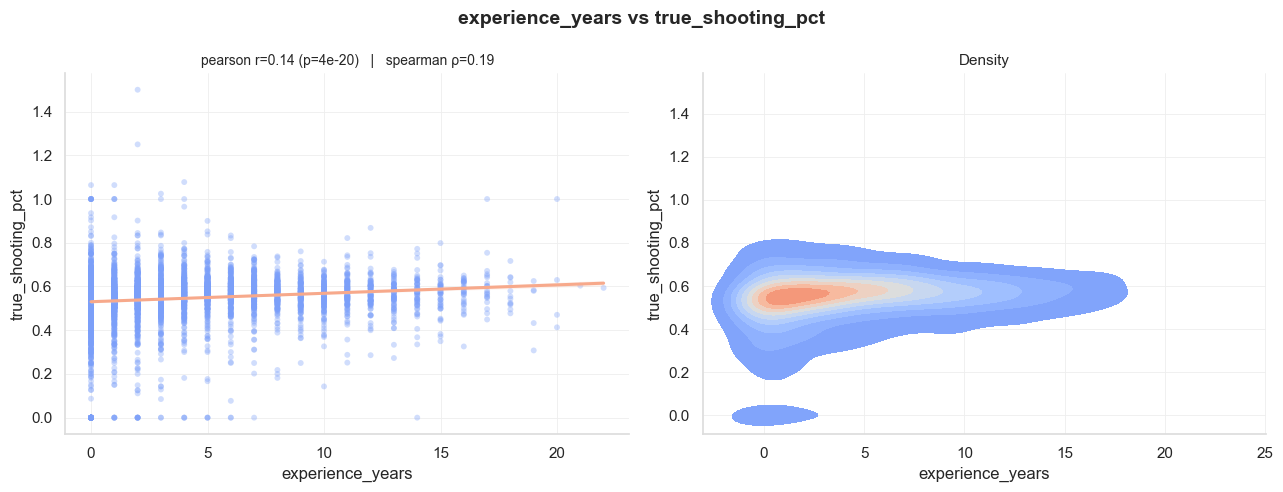

Spearman rho = 0.1928, p = 4.698e-39
Result: Significant


(0.19282432600405217, 4.6978425949896744e-39)

In [160]:
numeric_vs_numeric_test(data, "experience_years", "true_shooting_pct")

### Q11: Is shooting hand associated with playing position?

- **Variables:** `shoots`, `position_main`
- **Test:** Chi-square test of independence
- **H0:** shooting hand and position are independent.
- **H1:** shooting hand and position are associated.

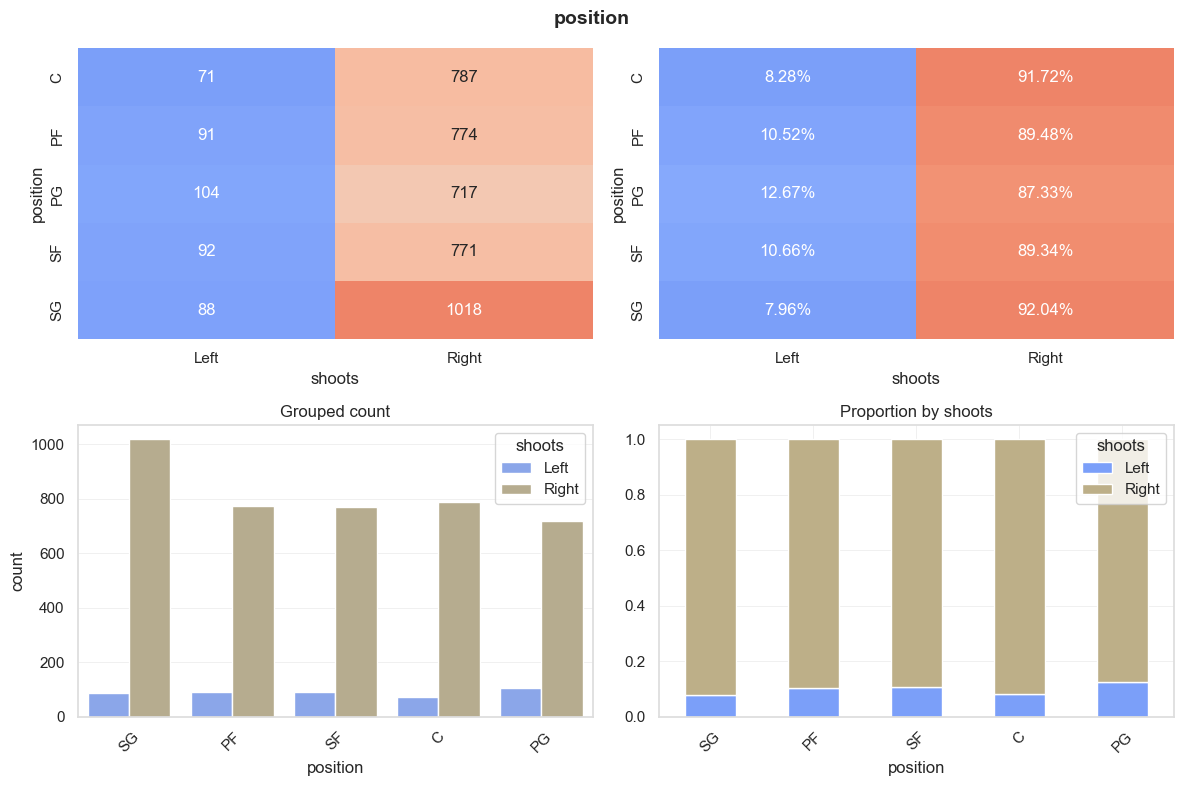

chi2_stat: 15.2271
p-value: 0.004253
Reject the Null Hypothesis
There IS a significant association between 'position' and 'shoots'.


In [167]:
compare_two_categorical(data, "position", "shoots")

### Q12: Do veteran players get more minutes than rookies?

- **Variables:** `experience_years_bin`, `minutes_played`
- **Test:** Welch's one-way ANOVA
- **H0:** the mean `minutes_played` is equal across experience groups.
- **H1:** at least one experience group differs.

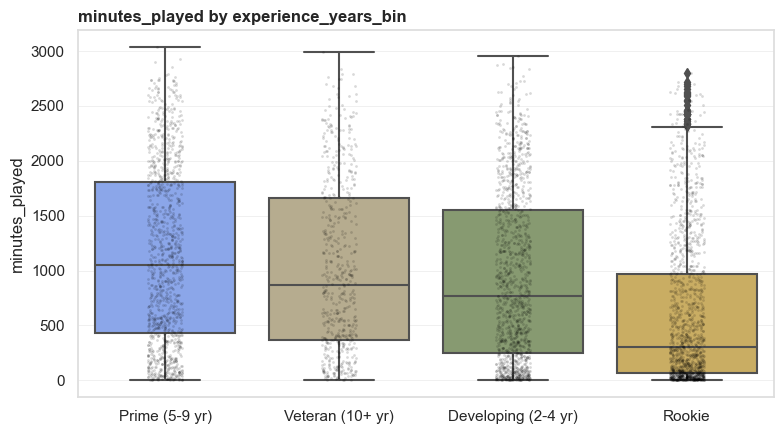

Test used: Welch ANOVA
F-stat = 137.0002
p-value = 1.225e-80
Result: Significant


(137.00015216908102, 1.225285164955166e-80, 'Significant')

In [163]:
anova_boxplot(data, "experience_years_bin", "minutes_played")
anova_test_pro(data, "experience_years_bin", "minutes_played", equal_var=False)

### Q13: Are undrafted players who make an NBA roster more shooting-efficient than drafted players?

- **Variables:** `is_undrafted`, `true_shooting_pct`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of shooting efficiency is the same regardless of draft status.
- **H1:** shooting efficiency differs by draft status.

Rationale: an undrafted player who sticks in the league may need to be more efficient to
justify a roster spot -- a survivorship-bias-style question, distinct from Q8 (which looks at
playing time rather than efficiency).

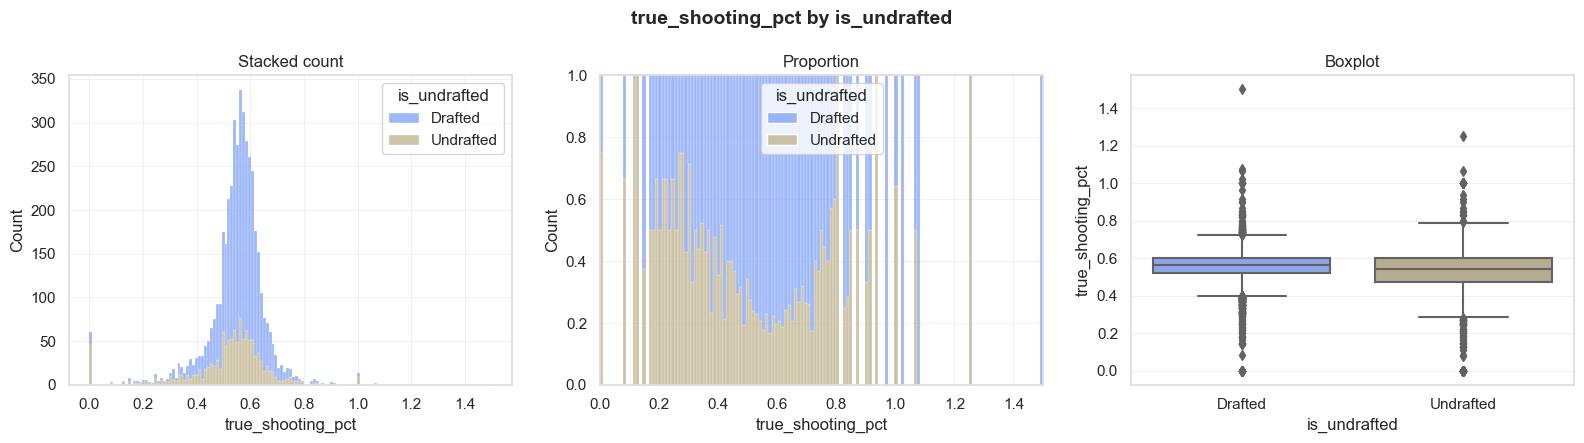

Shapiro group 'Drafted': p = 9.799e-47
Shapiro group 'Undrafted': p = 1.187e-29
Not normal after Box-Cox -> Mann-Whitney U
U = 2250345.0, p = 2.164e-12
Result: Significant


2.1639222450780544e-12

In [164]:
numeric_vs_categorical(data, "true_shooting_pct", "is_undrafted")

---
## Has Players' "Innate Ability" Improved?

**Claim:** an expert argues that, thanks to modern progress and better conditions, people's ability to develop and express their innate talent has improved compared to the past. As supporting evidence, the expert claims that the average *innate ability* of the players on the championship-winning team is higher in the **last 2 seasons** than it was **2 seasons before that**. The expert defines *innate ability* as **experience relative to age** (experience ÷ age) — the idea being that someone who has accumulated more career experience per year of life has converted more of their life into skill.

In [ ]:
# the champion team for each of the 4 most recent seasons on record
champ_recent = champ.merge(seasons, on="season_id").sort_values("season_id", ascending=False).head(4).sort_values("season_id").reset_index(drop=True)

print("4 most recent seasons with a recorded champion:")
print(champ_recent[["season_id", "season", "team_id"]].to_string(index=False))

# Most recent 2 seasons vs. the 2 seasons before those
last_2_seasons = champ_recent.iloc[2:]
prior_2_seasons = champ_recent.iloc[:2]

4 most recent seasons with a recorded champion:
 season_id  season  team_id
         4 2022-23        8
         5 2023-24       20
         6 2024-25       21
         7 2025-26       20


In [175]:
group_recent = data.merge(last_2_seasons[['season_id', 'team_id']])
group_recent = group_recent.query("games > 0 and age > 0").copy()
group_recent["innate_ability"] = group_recent["experience_years"] / group_recent["age"]

cols = ["player_id", "name", "season", "team_id", "age", "experience_years", "innate_ability"]
group_recent = group_recent[cols]
group_recent

,player_id,name,season,team_id,age,experience_years,innate_ability
0,1367,Shai Gilgeous-Alexander,2024-25,21,26,6,0.230769
1,2130,Jalen Williams,2024-25,21,23,2,0.086957
2,2121,Aaron Wiggins,2024-25,21,26,3,0.115385
3,1522,Isaiah Joe,2024-25,21,25,4,0.160000
4,1273,Luguentz Dort,2024-25,21,25,5,0.200000
5,1429,Isaiah Hartenstein,2024-25,21,26,6,0.230769
6,2086,Cason Wallace,2024-25,21,21,1,0.047619
7,1465,Chet Holmgren,2024-25,21,22,1,0.045455
8,2134,Kenrich Williams,2024-25,21,30,6,0.200000
9,1174,Alex Caruso,2024-25,21,30,7,0.233333


In [177]:
group_prior = data.merge(prior_2_seasons[['season_id', 'team_id']])
group_prior = group_prior.query("games > 0 and age > 0").copy()
group_prior["innate_ability"] = group_prior["experience_years"] / group_prior["age"]

cols = ["player_id", "name", "season", "team_id", "age", "experience_years", "innate_ability"]
group_prior = group_prior[cols]
group_prior

,player_id,name,season,team_id,age,experience_years,innate_ability
0,1539,Nikola JokiA,2022-23,8,27,7,0.259259
1,1752,Jamal Murray,2022-23,8,25,6,0.240000
2,1377,Aaron Gordon,2022-23,8,27,8,0.296296
3,1851,Michael Porter Jr.,2022-23,8,24,3,0.125000
4,1128,Bruce Brown,2022-23,8,26,4,0.153846
5,1157,Kentavious Caldwell-Pope,2022-23,8,29,9,0.310345
6,1507,Reggie Jackson,2022-23,8,32,11,0.343750
7,1487,Bones Hyland,2022-23,8,22,1,0.045455
8,1142,Thomas Bryant,2022-23,8,25,5,0.200000
9,1394,Jeff Green,2022-23,8,36,15,0.416667


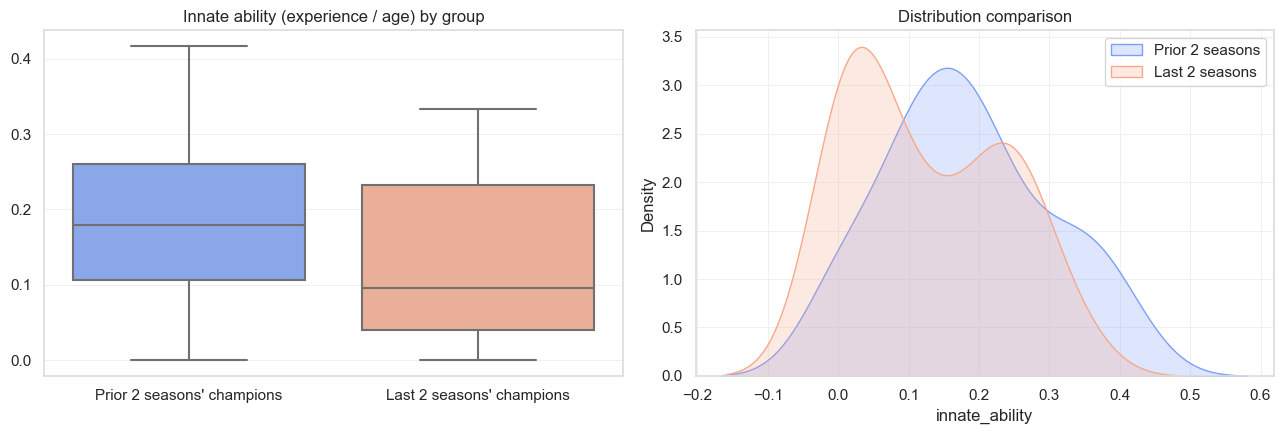

Mean innate ability, prior 2 seasons' champions: 0.1838
Mean innate ability, last 2 seasons' champions:  0.1260


In [170]:
# compare the two groups' innate-ability distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=[group_prior["innate_ability"], group_recent["innate_ability"]], ax=axes[0], palette=[Blue, Orange])
axes[0].set_xticklabels(["Prior 2 seasons' champions", "Last 2 seasons' champions"])
axes[0].set_title("Innate ability (experience / age) by group")

sns.kdeplot(group_prior["innate_ability"], fill=True, label="Prior 2 seasons", color=Blue, ax=axes[1])
sns.kdeplot(group_recent["innate_ability"], fill=True, label="Last 2 seasons", color=Orange, ax=axes[1])
axes[1].set_title("Distribution comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean innate ability, prior 2 seasons' champions: {group_prior['innate_ability'].mean():.4f}")
print(f"Mean innate ability, last 2 seasons' champions:  {group_recent['innate_ability'].mean():.4f}")

In [171]:
alpha = 0.05

shapiro_p_recent = stats.shapiro(group_recent["innate_ability"]).pvalue
shapiro_p_prior = stats.shapiro(group_prior["innate_ability"]).pvalue
print(f"Shapiro (last 2 seasons' champions):  p = {shapiro_p_recent:.4g}")
print(f"Shapiro (prior 2 seasons' champions): p = {shapiro_p_prior:.4g}")

Shapiro (last 2 seasons' champions):  p = 0.001088
Shapiro (prior 2 seasons' champions): p = 0.1234


In [173]:
stat, p = stats.mannwhitneyu(group_recent["innate_ability"], group_prior["innate_ability"],
                                  alternative="greater")
test_used = "Mann-Whitney U (one-sided: recent > prior)"
print(f"\nMann-Whitney U (one-sided: recent > prior) used.")
print(f"statistic = {stat:.4f}, p = {p:.4g}")


Mann-Whitney U (one-sided: recent > prior) used.
statistic = 633.5000, p = 0.9802


**Result:** p >= alpha, fail to reject H0 — no significant evidence for the expert's claim in this specific example.

- This tests one specific example (one team's roster, twice), not the general claim about society or the league as a whole — even a clear result here would only support the claim's illustration, not prove the broader statement.
- A champion roster's experience mix is shaped by team-building strategy (a team can win by combining a few veteran stars with young role players), not just by how much "innate ability" individual players have converted to skill — the metric conflates roster construction with individual development.
- experience_at_season uses nba_debut as the start of a career; it does not account for time missed to injury or time spent outside the NBA (overseas, G League), so it is a reasonable but imperfect proxy for actual playing experience.
- With only two seasons per group, the sample size is small and roster-dependent — a different pair of seasons or a different champion could change the conclusion.